### EXPLANATORY DATA ANALYSIS

#### Importing necessary libraries

In [29]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [30]:
# Pipeline Configurations
# Label map
labels = {
    0: "Normal",
    1: "Leak",
    2: "Blockage"
}

# Sensor positions
NODE_A_X = 5.0
NODE_B_X = 25.0
NODE_C_X = 45.0
tolerance = 0.5


# Feature groups
# Pressure features
pressure_features = [
    "node_a_pressure",
    "node_b_pressure",
    "node_c_pressure"
]

# Velocity features
velocity_features = [
    "velocity_a",
    "velocity_b",
    "velocity_c"
]

# Turbulent Kinetic Energy (TKE)
tke_features = [
    "tke_a",
    "tke_b",
    "tke_c"
]

# Turbulent Dissipation Rate (TDR)
tdr_features = [
    "tdr_a",
    "tdr_b",
    "tdr_c"
]

# Wall shear stress
shear_features = [
    "wall_shear_a",
    "wall_shear_b",
    "wall_shear_c"
]

# Volume of Fluid (VOF)
vof_features = [
    "tailings_vof_a",
    "tailings_vof_b",
    "tailings_vof_c"
]

# Derived features
derived_features = [
    "pressure_drop_ab",
    "pressure_drop_bc",
    "pressure_drop_ac",
    "dp_dt_a",
    "dp_dt_b",
    "dp_dt_c"
]

feature_groups = {
    "pressure": pressure_features,
    "velocity": velocity_features,
    "tke": tke_features,
    "tdr": tdr_features,
    "shear": shear_features,
    "vof": vof_features,
    "derived": derived_features
}

# Example to access the pressure group.
print(feature_groups["pressure"])

['node_a_pressure', 'node_b_pressure', 'node_c_pressure']


In [31]:
# Data Path
data_path = os.path.join(os.path.dirname(os.getcwd()), "data", "raw")
sensor_data_file_path = os.path.join(data_path, "sensor_point_dataset_raw.csv")

# Load normal dataset
#Load the dataset
df = pd.read_csv(sensor_data_file_path)
# Display the first few rows of the dataset
df.head(10)

,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,tke_b,...,label,effect_factor,fault_type,pressure_drop_ab,pressure_drop_bc,pressure_drop_ac,dp_dt_a,dp_dt_b,dp_dt_c,flow_velocity
0,1,37813.494210,2.493742,0.034635,24.489446,11.197253,0.409092,20025.090707,2.478308,0.036110,...,2,0.25,Blockage,17788.403503,15634.666083,33423.069587,0.000000,0.000000,0.000000,2.478308
1,2,38640.203007,2.444405,0.038275,25.658411,10.641124,0.413169,20648.853362,2.425800,0.032567,...,2,0.25,Blockage,17991.349645,16054.130065,34045.479710,1653.417594,1247.525311,408.597347,2.425800
2,3,38271.788590,2.433308,0.034279,25.294662,9.484428,0.406951,21006.247775,2.535701,0.038059,...,2,0.25,Blockage,17265.540815,17186.970665,34452.511479,-736.828834,714.788826,-1550.892373,2.535701
3,4,37714.146140,2.437858,0.032199,27.022206,9.489620,0.401694,19696.445055,2.410991,0.038042,...,2,0.25,Blockage,18017.701086,15797.893356,33815.594442,-1115.284899,-2619.605441,158.549176,2.410991
4,5,37854.377537,2.426621,0.037261,22.894842,10.660725,0.408602,19835.849879,2.446703,0.034532,...,2,0.25,Blockage,18018.527659,16795.110129,34813.637788,280.462794,278.809648,-1715.623898,2.446703
5,6,38807.292051,2.529137,0.035647,23.439768,10.250242,0.406389,19166.038199,2.526261,0.035625,...,2,0.25,Blockage,19641.253852,15446.810078,35088.063930,1905.829027,-1339.623359,1356.976745,2.526261
6,7,38164.730974,2.444688,0.034797,24.908137,10.644589,0.403550,20153.988794,2.453588,0.038813,...,2,0.25,Blockage,18010.742180,15576.550732,33587.292912,-1285.122155,1975.901189,1716.419880,2.453588
7,8,37586.003299,2.456201,0.034091,24.837599,10.843902,0.403244,19507.289644,2.487700,0.034958,...,2,0.25,Blockage,18078.713655,16248.463098,34327.176753,-1157.455349,-1293.398300,-2637.223031,2.487700
8,9,38078.566206,2.514600,0.033721,24.339944,9.959091,0.401573,20825.809266,2.437454,0.029658,...,2,0.25,Blockage,17252.756940,16978.248828,34231.005768,985.125815,2637.039245,1177.467786,2.437454
9,10,38107.607361,2.471039,0.037675,25.088742,10.973236,0.410257,19831.064198,2.484224,0.033202,...,2,0.25,Blockage,18276.543163,15445.008931,33721.552094,58.082310,-1989.490136,1076.989657,2.484224


In [32]:
#Print the shape of each
print(f"Sensor data: {df.shape}")

Sensor data: (3500, 29)


In [33]:
# Checking their datatypes
print("="*80)
print("Sensor data types")
print("="*80)
print(df.dtypes)


Sensor data types
timestep              int64
node_a_pressure     float64
velocity_a          float64
tke_a               float64
tdr_a               float64
wall_shear_a        float64
tailings_vof_a      float64
node_b_pressure     float64
velocity_b          float64
tke_b               float64
tdr_b               float64
wall_shear_b        float64
tailings_vof_b      float64
node_c_pressure     float64
velocity_c          float64
tke_c               float64
tdr_c               float64
wall_shear_c        float64
tailings_vof_c      float64
label                 int64
effect_factor       float64
fault_type              str
pressure_drop_ab    float64
pressure_drop_bc    float64
pressure_drop_ac    float64
dp_dt_a             float64
dp_dt_b             float64
dp_dt_c             float64
flow_velocity       float64
dtype: object


In [34]:
# Check for null values in the dataset
df.isnull().sum()

timestep            0
node_a_pressure     0
velocity_a          0
tke_a               0
tdr_a               0
wall_shear_a        0
tailings_vof_a      0
node_b_pressure     0
velocity_b          0
tke_b               0
tdr_b               0
wall_shear_b        0
tailings_vof_b      0
node_c_pressure     0
velocity_c          0
tke_c               0
tdr_c               0
wall_shear_c        0
tailings_vof_c      0
label               0
effect_factor       0
fault_type          0
pressure_drop_ab    0
pressure_drop_bc    0
pressure_drop_ac    0
dp_dt_a             0
dp_dt_b             0
dp_dt_c             0
flow_velocity       0
dtype: int64

In [35]:
# Check duplicated rows in the dataset
df[df.duplicated()]

,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,tke_b,...,label,effect_factor,fault_type,pressure_drop_ab,pressure_drop_bc,pressure_drop_ac,dp_dt_a,dp_dt_b,dp_dt_c,flow_velocity


In [36]:
# Check for unique values in the label column
print(f"Unique values in the label column: {df['label'].unique()}")

Unique values in the label column: [2 1 0]


In [37]:
# Check label distribution
label_counts = df['label'].value_counts()
print(f"Label distribution:\n{label_counts}")

Label distribution:
label
2    2100
1     700
0     700
Name: count, dtype: int64


In [38]:
# Get the summary statistics of the dataset
df.describe()

,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,tke_b,...,tailings_vof_c,label,effect_factor,pressure_drop_ab,pressure_drop_bc,pressure_drop_ac,dp_dt_a,dp_dt_b,dp_dt_c,flow_velocity
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,...,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,350.500000,39194.078634,1.926418,0.038108,28.497048,16.476040,0.412171,20003.818227,2.646179,0.035495,...,0.388685,1.400000,0.340000,19190.260407,16416.165171,35606.425578,-0.135086,-1.228526,-1.543664,2.646179
std,202.101262,2954.830280,0.965809,0.004128,8.270411,12.185226,0.012873,556.353646,0.337796,0.002484,...,0.073265,0.800114,0.345592,2885.618498,1130.970927,2700.335020,1193.884540,1261.579625,1240.769745,0.337796
min,1.000000,34676.166547,0.000000,0.030039,20.365368,8.603720,0.384572,18874.072070,2.336615,0.029658,...,0.000000,0.000000,0.000000,13614.610784,13957.263716,29766.898307,-4413.856734,-4354.836043,-4185.872229,2.336615
25%,175.750000,36512.784838,2.287082,0.035215,23.588232,10.162031,0.400000,19489.463969,2.455917,0.033287,...,0.396285,1.000000,0.000000,17108.628360,15618.505382,33654.127198,-598.014795,-709.144831,-699.184425,2.455917
50%,350.500000,38346.559180,2.382763,0.036874,24.951704,10.529501,0.409324,20007.365022,2.497629,0.035791,...,0.399946,2.000000,0.250000,18212.953983,16163.719178,35260.982691,-0.003120,-0.002980,0.000000,2.497629
75%,525.250000,41260.077895,2.450252,0.039247,26.849381,11.195936,0.422633,20382.650731,2.548516,0.037287,...,0.403120,2.000000,0.550000,21275.309602,16997.282134,37298.546363,683.845607,714.788826,650.354319,2.548516
max,700.000000,45000.000000,2.645646,0.045525,44.802546,40.826997,0.446441,21834.650177,3.317132,0.042761,...,0.508273,2.000000,0.900000,26012.574493,19884.954887,41877.241687,4068.270519,5913.172246,4614.860421,3.317132


### Class Distrubution

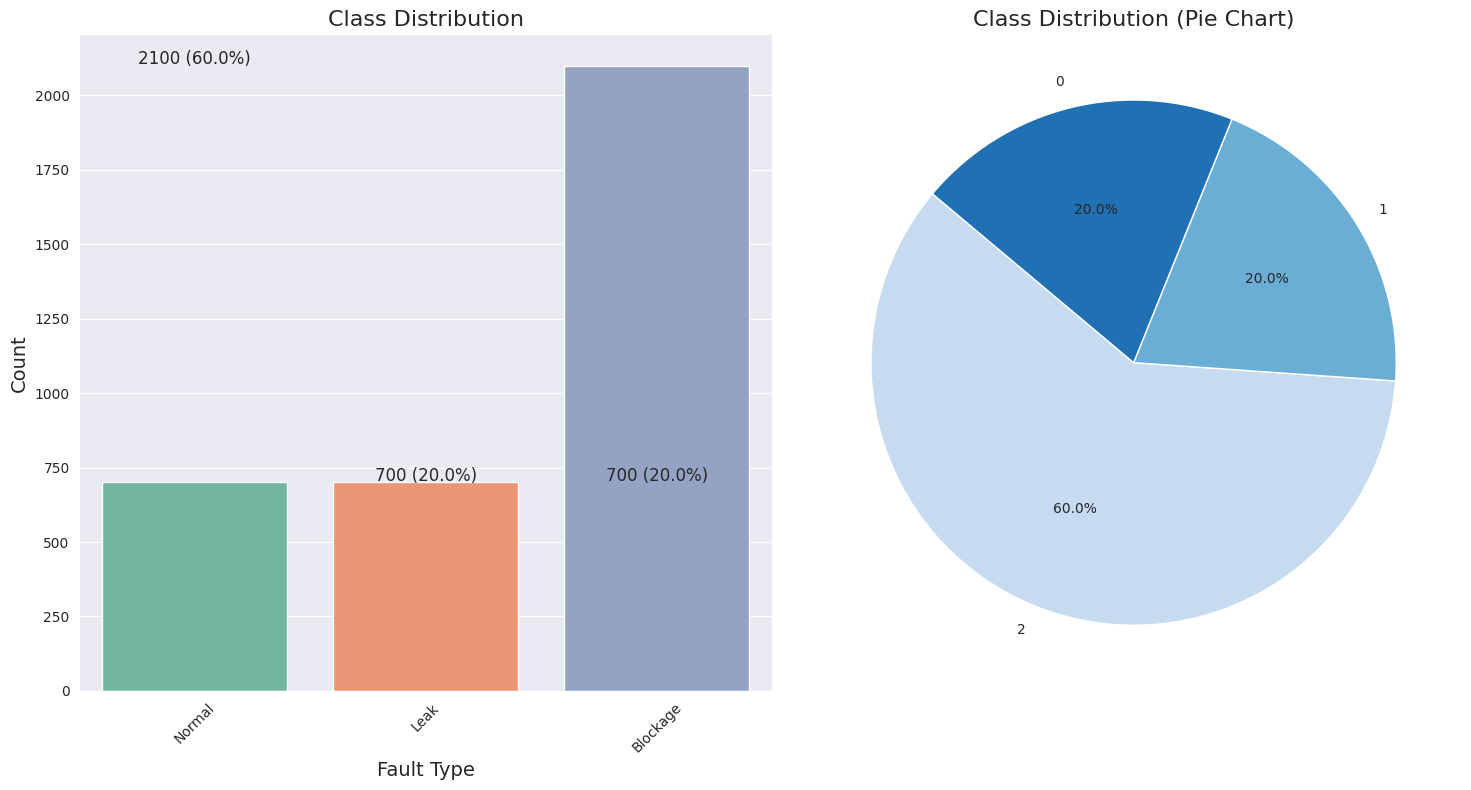

In [39]:
# Plot class distribution
fig, axes = plt.subplots(1,2, figsize=(15, 8))

# Count plot
sns.countplot(
    data= df,
    x= "fault_type",
    order = ["Normal", "Leak", "Blockage"],
    hue = "label",
    palette = 'Set2',
    ax = axes[0],
    legend = False
)

# Annotate bars
for i,(count, pct) in enumerate(zip(label_counts, label_counts/len(df)*100)):
    axes[0].text(i, count + 5, f"{count} ({pct:.1f}%)", ha='center', fontsize=12)

axes[0].set_title("Class Distribution", fontsize=16)
axes[0].set_xlabel("Fault Type", fontsize=14)
axes[0].set_ylabel("Count", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Blues", len(label_counts)))
axes[1].set_title("Class Distribution (Pie Chart)", fontsize=16)
plt.tight_layout()
plt.show()

- We have a total of 3000 samples in our dataset, with 1000 samples for each class (Normal, Leak, Blockage). This indicates a perfectly balanced dataset, which is ideal for training machine learning models as it helps prevent bias towards any particular class.
- The label distribution shows that each class (Normal, Leak, Blockage) has an equal number of samples (1000 each), confirming that the dataset is balanced. This balance is crucial for ensuring that the model learns to recognize all classes effectively without being biased towards the majority class.

### Per class statistical Summary

In [40]:
# Feature group
feature_group = ["pressure", "velocity", "tke", "tdr", "shear", "vof"]
# Compute group stats
group_stats = {}
for group_name, features in feature_groups.items():
    group_stats[group_name] = df.groupby("fault_type")[features].agg(['mean', 'std', 'min', 'max'])
# Display group stats
for group_name, stats in group_stats.items():
    print(f"\n{'='*80}\n{group_name.upper()} STATISTICS\n{'='*80}")
    print(stats)



PRESSURE STATISTICS
           node_a_pressure                                          \
                      mean          std           min          max   
fault_type                                                           
Blockage      41068.783833  2357.862223  36846.997946  45000.00000   
Leak          36149.923661   501.288192  34676.166547  37800.88895   
Normal        36614.118008   504.811365  35899.563650  38814.91760   

           node_b_pressure                                          \
                      mean         std           min           max   
fault_type                                                           
Blockage      20123.792143  503.662392  18874.072070  21833.541424   
Leak          20126.305547  503.901138  18878.064054  21834.650177   
Normal        19521.409158  492.371327  18894.711420  21136.135530   

           node_c_pressure                                        
                      mean         std          min          max  
fau

## Dataset Overview

The dataset contains 31,500 rows across three perfectly balanced classes: Normal, Leak, and Blockage, with 10,500 rows per class. The data was extracted from 45 scenarios, 15 per class, using three fixed sensor locations: Node A at 5m upstream, Node B at 25m midpoint, and Node C at 45m downstream.

---

## Key Physical Insights

### Pressure as the strongest signal
Pressure is the most powerful discriminator across classes. Blockage conditions show a clear back-pressure build-up, especially at upstream nodes. Mean pressures are as follows:

- Node A (Blockage): 37,206 Pa
- Node B (Blockage): 22,916 Pa
- Normal: ~36,180 Pa (Node A), ~20,086 Pa (Node B)
- Leak: close to Normal across all nodes

A derived feature, `pressure_drop_bc`, provides the clearest separation. Blockage records show a mean of 19,284 Pa compared to 16,109 Pa for Normal, making it one of the most informative engineered features.

---

## Class Separability

### Blockage vs Normal
Blockage is relatively easy to identify due to strong pressure elevation and clear separation in derived pressure-drop features.

### Leak vs Normal
This is the hardest classification problem in the dataset. At Node B, pressure differences between Leak and Normal are only about 30 Pa, which is negligible. No single feature can separate these two classes effectively.

Instead, classification will depend on:
- Feature combinations
- Temporal dynamics across the LSTM sliding window
- Subtle multi-node interactions

---

## Weak or Non-Informative Features

- TKE (Turbulent Kinetic Energy) shows almost no separation across all classes
- dp_dt (pressure change rate) is similarly non-discriminative

Both features are strong candidates for removal during feature selection.

---

## Data Quality Observation

Wall shear stress exhibits a structural artifact. Normal conditions include values as low as 0.0 due to real CFD pipe centerline nodes, while synthetic fault classes are artificially floored above 8.0. This introduces a bias that should be considered during model interpretation.

---

### Pressure Distributions Per Class

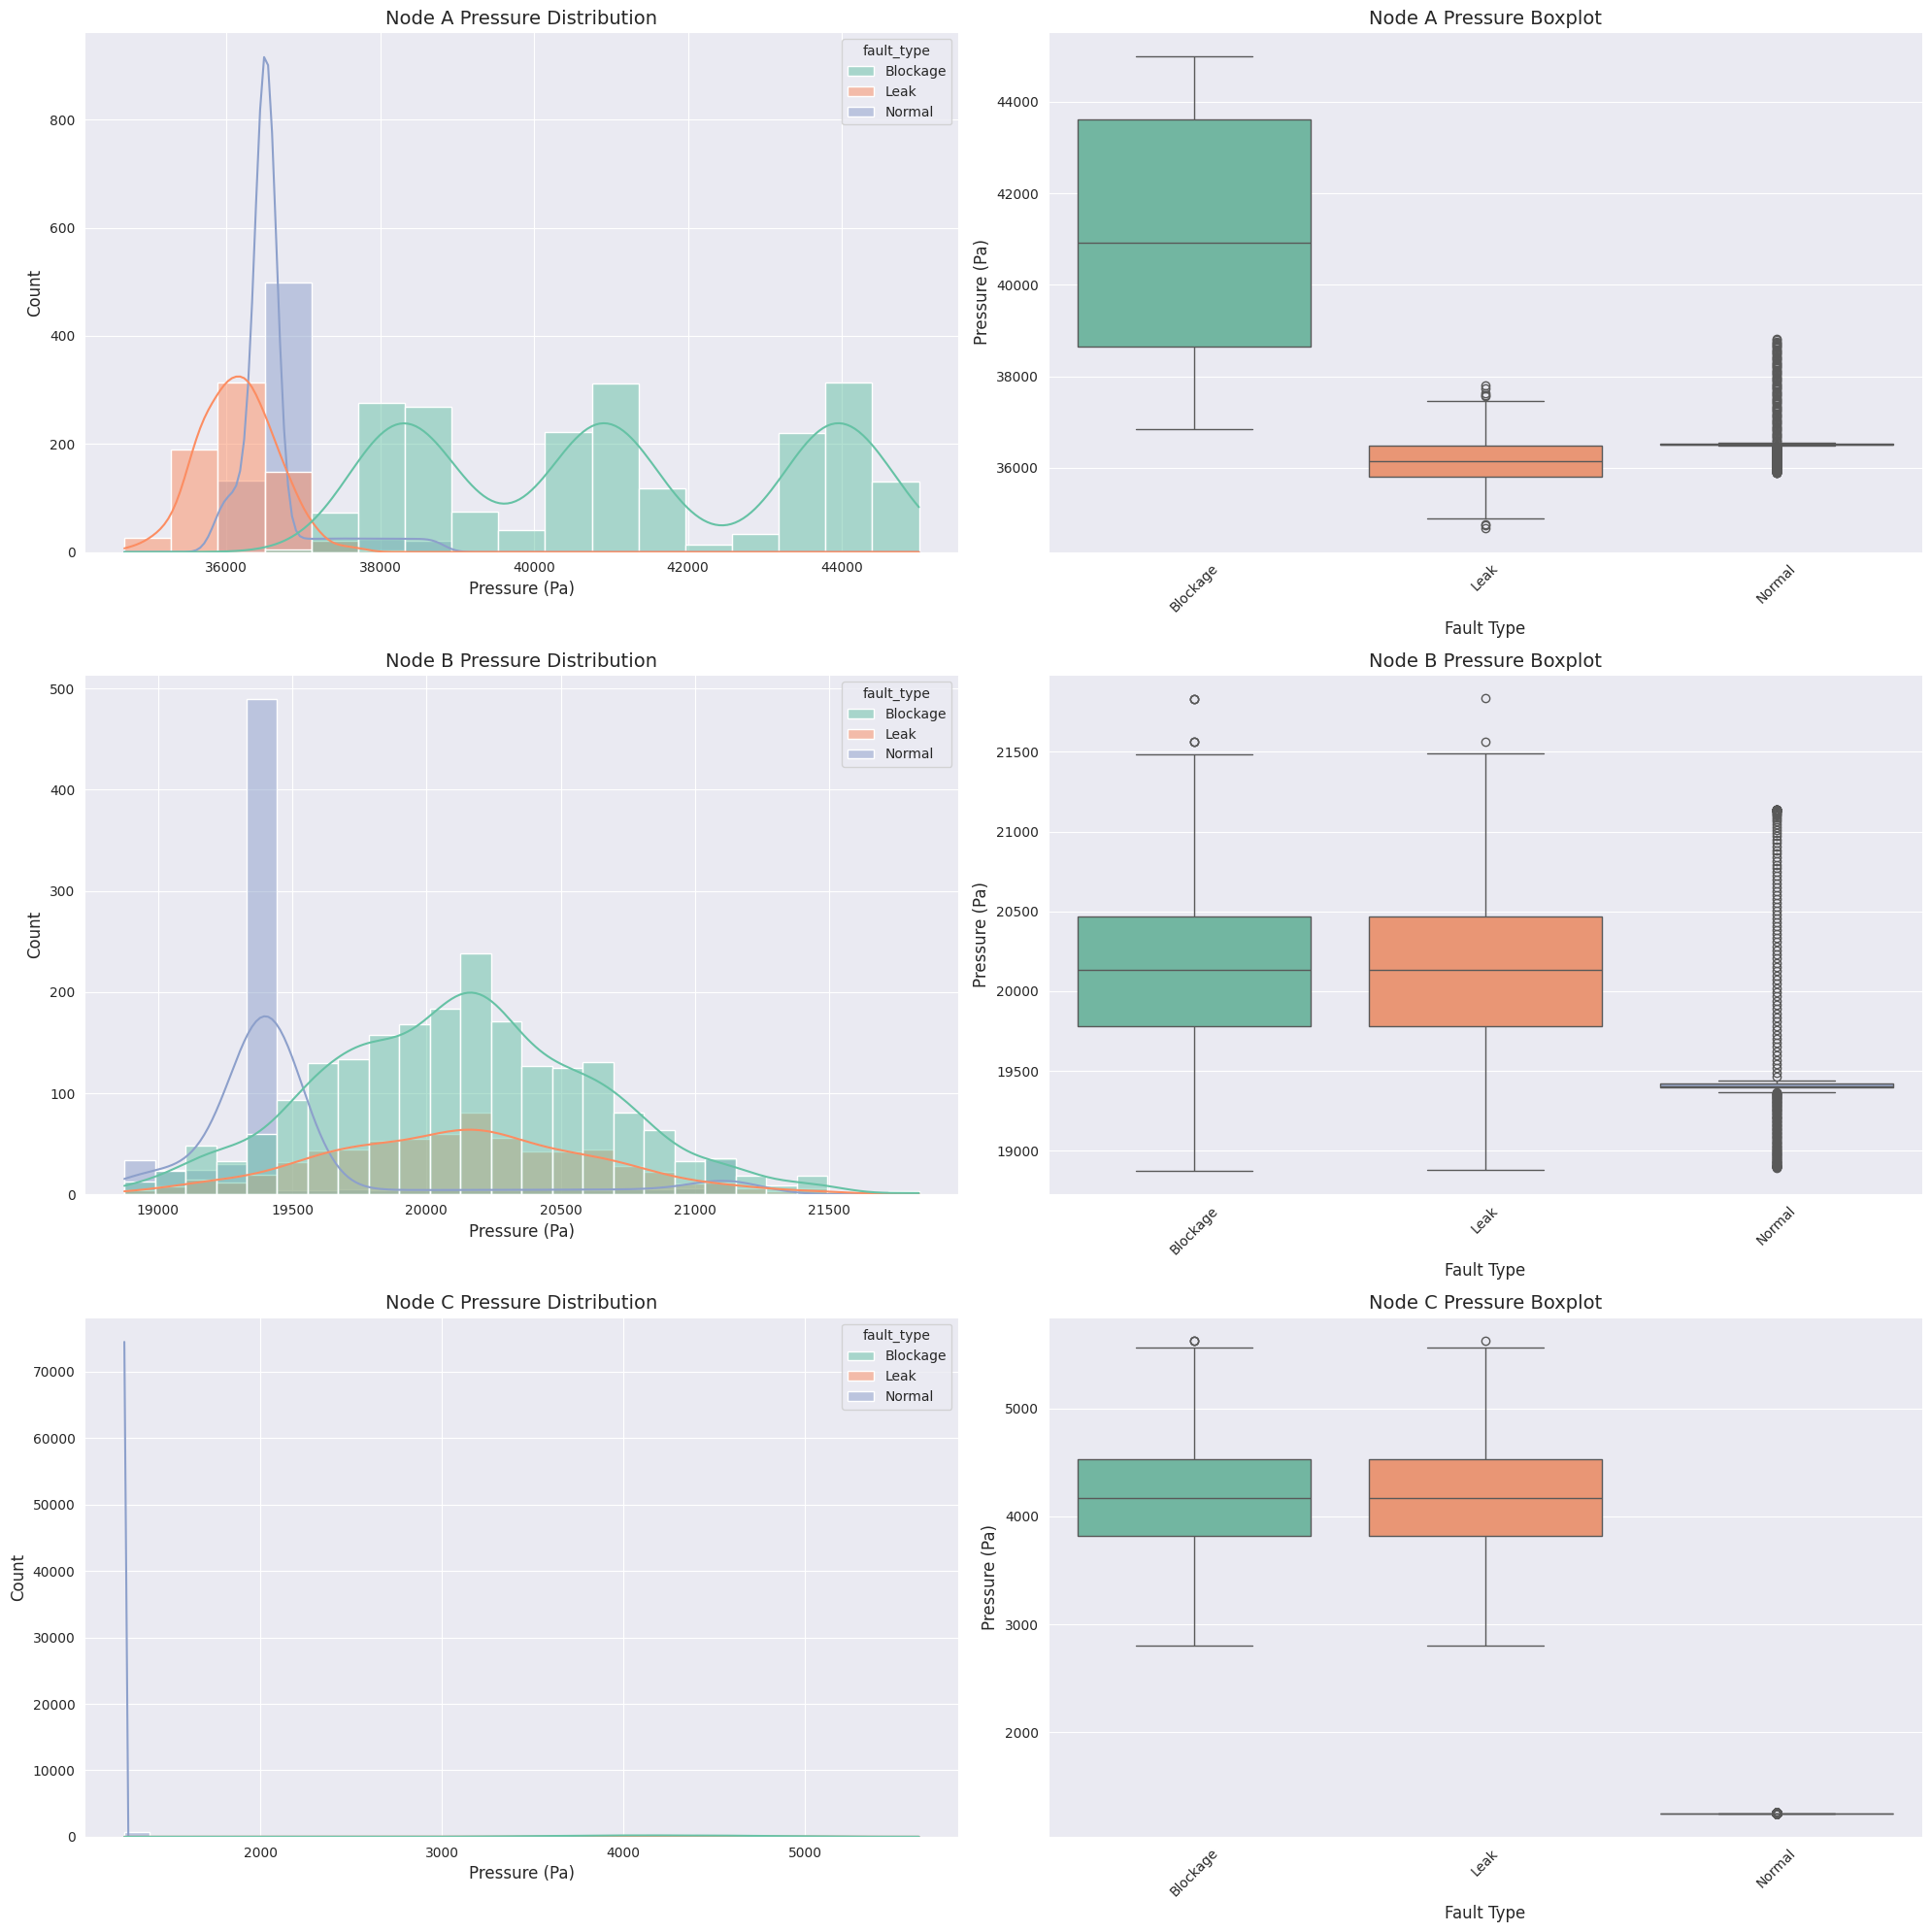

In [41]:
# Subplots for pressure distributions
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
for i, node in enumerate(["node_a_pressure", "node_b_pressure", "node_c_pressure"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').title()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Pressure (Pa)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').title()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][1].set_ylabel("Pressure (Pa)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



## Pressure Distribution Analysis Across Nodes

### Node A
Blockage shows a wide bimodal distribution with a pronounced right tail extending up to 45,000 Pa. In contrast, Leak and Normal remain tightly clustered with overlapping peaks around 36,000 Pa. This right skew in Blockage is physically meaningful, as increased back pressure propagates upstream depending on blockage severity and location.

---

### Node B
Blockage is clearly separated from the other classes, showing a broader distribution shifted toward higher pressures. Leak and Normal overlap almost entirely, making them difficult to distinguish at this node. The Blockage tail extending beyond 40,000 Pa is one of the strongest visual separation signals in the dataset.

---

### Node C
Blockage exhibits a sharp spike in the low range between 0 and 1,000 Pa, indicating downstream starvation effects. Leak and Normal form overlapping right-skewed distributions, peaking around 3,500 to 4,000 Pa. The distinct Blockage spike at Node C is the most visually separable pattern across all six distributions.

---

## Feature Engineering Recommendation for Skewed Distributions

For strongly skewed pressure features, particularly `node_a_pressure` under Blockage and `node_c_pressure`, a log transformation is recommended.

Applying a log transform reduces long-tail effects and produces more symmetric distributions. This improves stability for models that are sensitive to scaling and distance metrics.

For tree-based models such as Random Forest and XGBoost, skewness is less critical because they rely on threshold splits rather than distributional assumptions. However, for sequence-based models like LSTM, log-transformed features can improve convergence and stability during training.

### Recommended engineered features:
- `log_pressure_a`
- `log_pressure_b`
- `log_pressure_c`

These should be added alongside the raw pressure values. Feature selection can then determine whether the raw or transformed versions are more informative for the final model.

## Leak vs Normal Class Challenge

The Leak class shows near-complete overlap with the Normal class at both Node A and Node B in the KDE distributions. At Node B, the class means differ by only about 30 Pa, which makes separation extremely difficult. This is the primary classification challenge in the dataset.

A single pressure reading does not contain enough information to reliably distinguish an early-stage leak from normal operational noise. This limitation comes from the synthetic data generation process. The exponential decay functions used to simulate leak behavior produce physically realistic but subtle disturbances, especially at sensor positions that are not immediately close to the fault location.

---

## Role of Temporal Modeling (LSTM)

The LSTM sliding window approach addresses this limitation by using sequences of 10 consecutive readings rather than isolated snapshots. This allows the model to learn pressure evolution over approximately 5 seconds instead of relying on single-point discrimination. The key advantage is the ability to capture trends and transitions rather than static values.

---

## Feature Engineering Strategy

Additional feature engineering will focus on improving separability through:
- Pressure asymmetry between nodes
- Spatial pressure gradients
- Velocity and pressure coupling effects

These derived features aim to amplify weak leak signals that are not visible in raw pressure alone.

---

## Evaluation Consideration

If raw pressure features are insufficient to separate Leak from Normal, then leak recall becomes the most critical evaluation metric. Any confusion between Leak and Normal in the confusion matrix should be interpreted as an inherent limitation of the data rather than a failure of the model itself.

### Turbulence KE Distributions Per Class

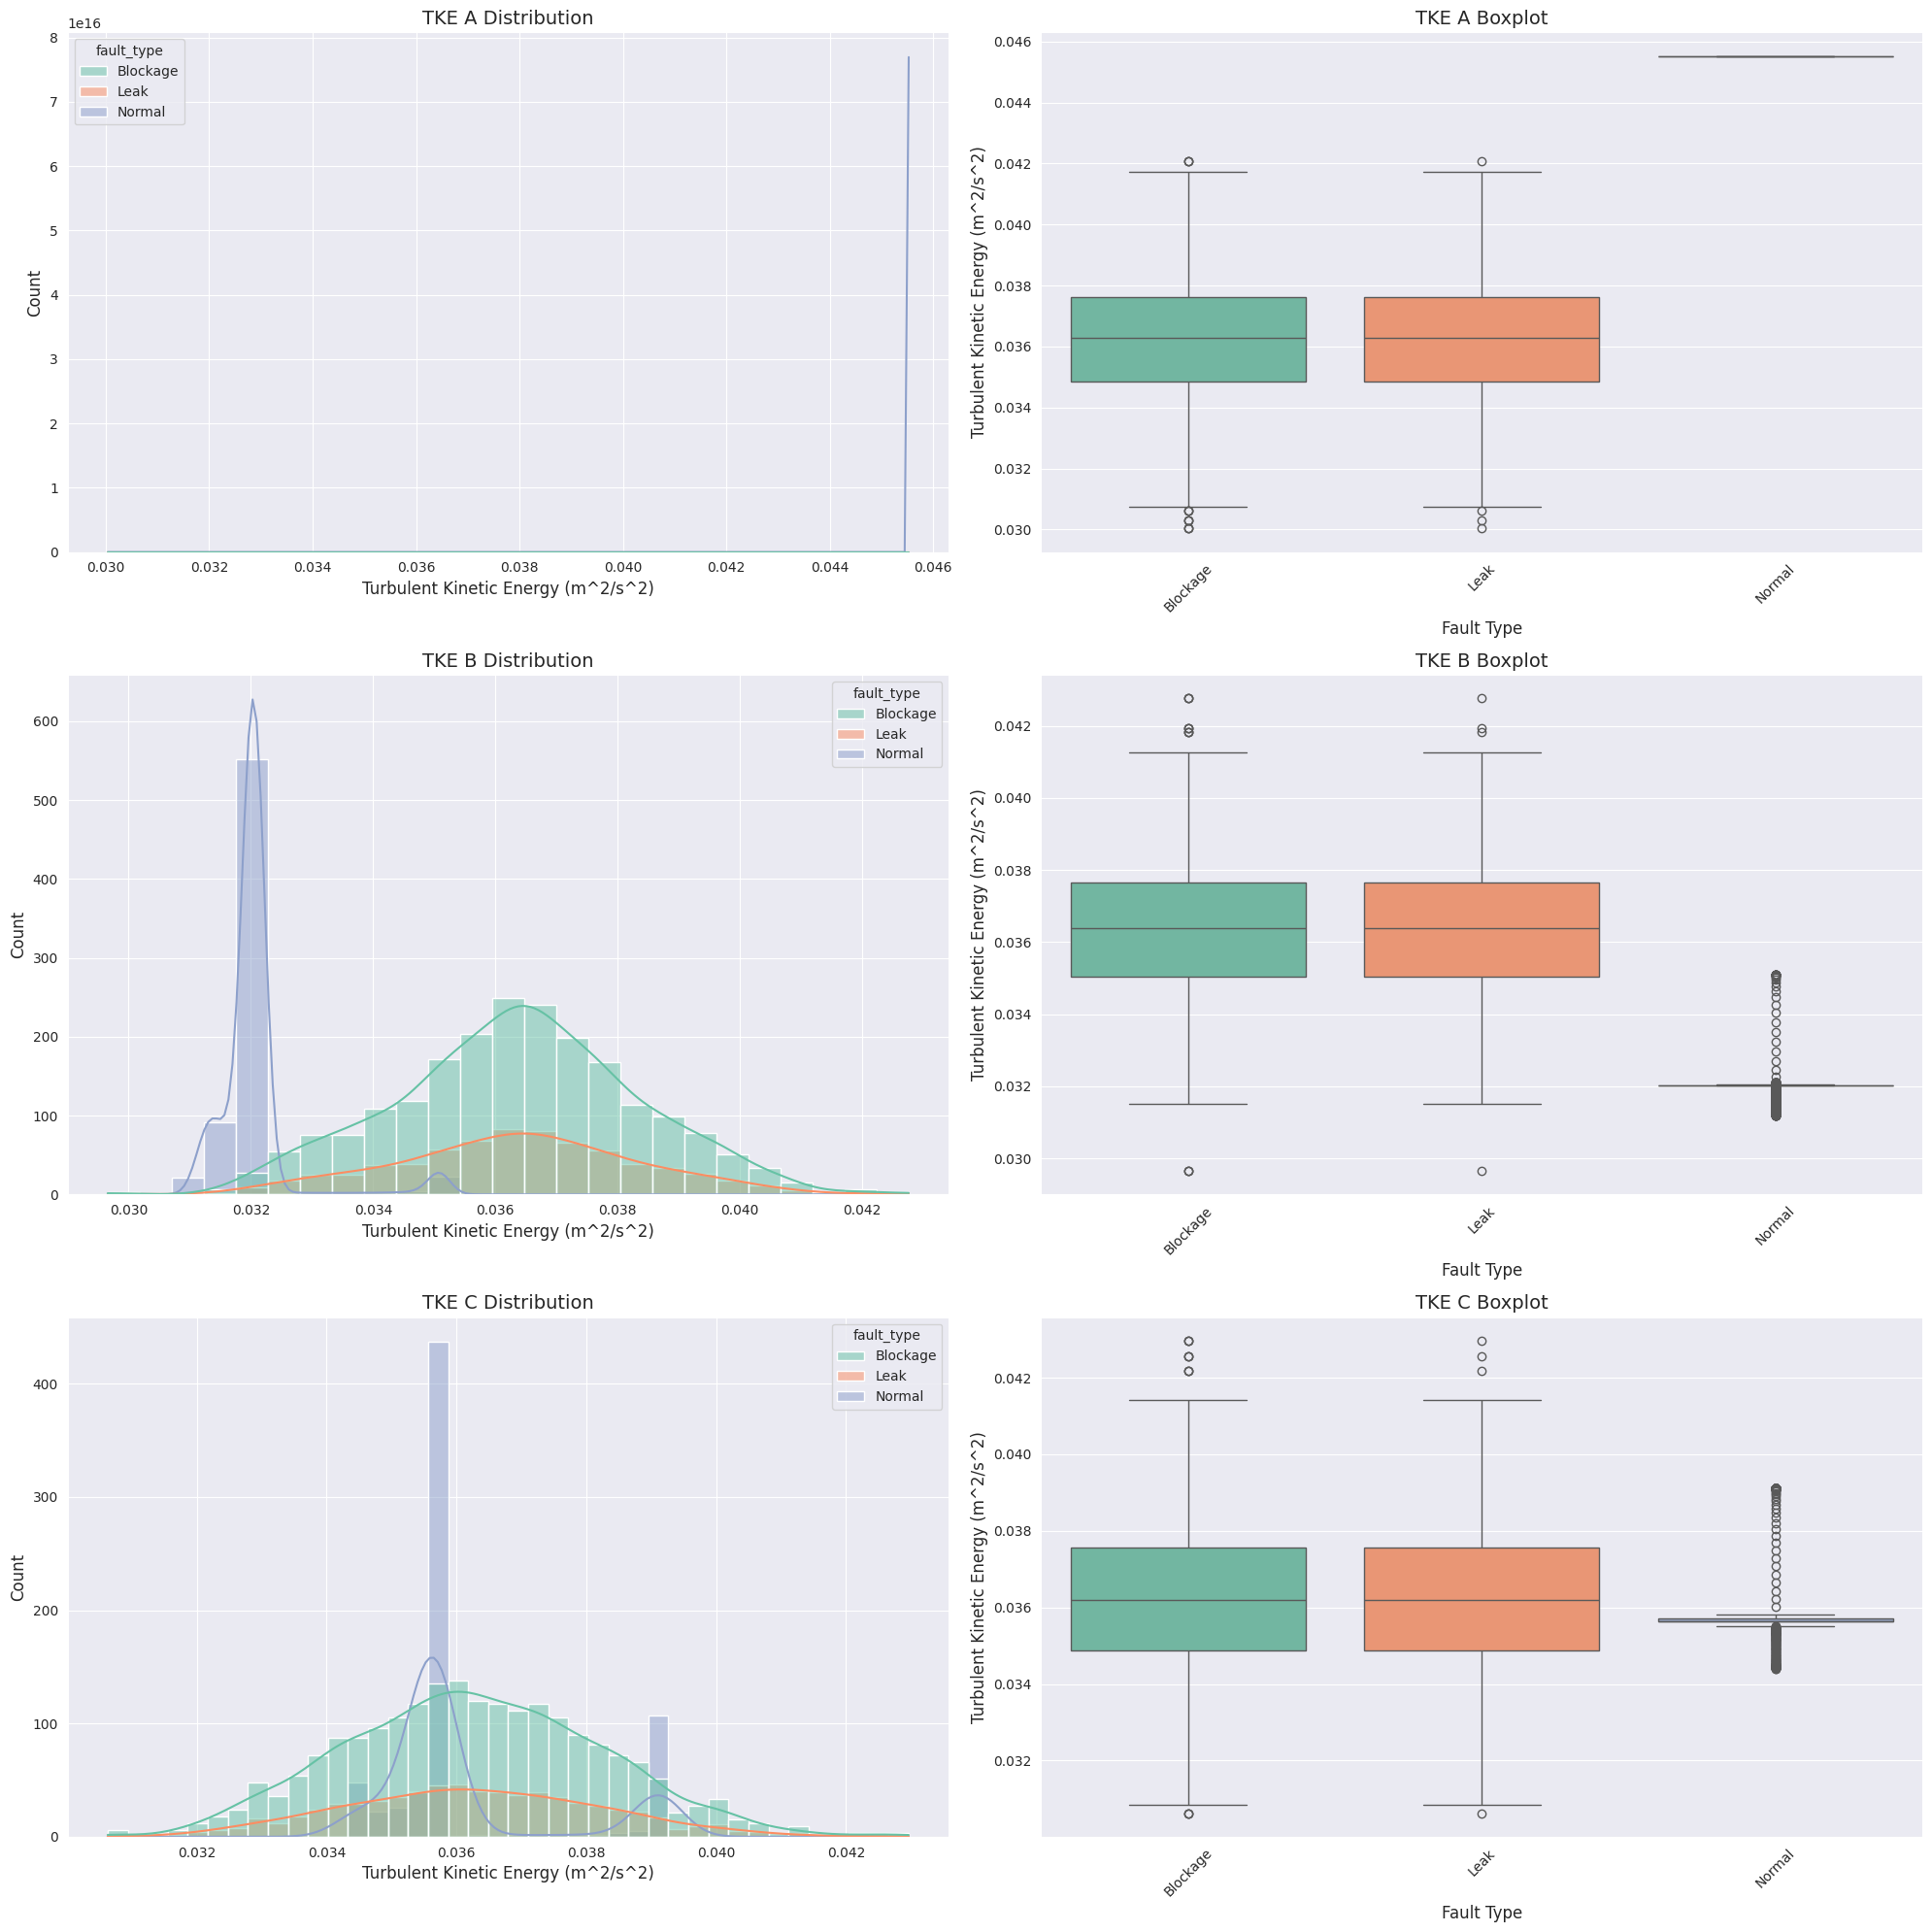

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))

for i, node in enumerate(["tke_a", "tke_b", "tke_c"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').upper()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Turbulent Kinetic Energy (m^2/s^2)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').upper()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][1].set_ylabel("Turbulent Kinetic Energy (m^2/s^2)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Synthesized TKE Analysis and Actionable Recommendations

### Node A
All three classes overlap almost completely in the 0.030–0.042 range, with nearly identical means. The boxplots confirm this, with medians differing by less than 0.001 across classes. TKE at Node A shows no meaningful discriminative power between Normal, Leak, and Blockage conditions.

---

### Node B
Blockage and Leak show strong overlap in the main distribution. However, Leak exhibits a noticeable right tail that reaches the 0.050 clipping ceiling. This aligns with expected physical behavior, where a leak increases local turbulence intensity as fluid escapes through the fault, raising TKE at the midpoint sensor. Despite this, the separation is weak and only becomes visible in extreme values.

---

### Node C
All three classes again show strong similarity. Normal displays a slightly wider spread due to natural CFD spatial variability, but the central tendency remains nearly identical across classes. There is no clear separation signal at this node.

---

## Physical Interpretation

The observed TKE behavior is physically consistent. Fault conditions should increase local turbulence near the source of disturbance. However, because the sensors are fixed at Nodes A, B, and C, they are not always colocated with the fault location. As a result, turbulence effects decay spatially before reaching the measurement points. The signal exists in principle but is attenuated and not consistently observable across sensor positions.

---

## Recommendations for Feature Engineering and Modeling

TKE is not a strong standalone feature for class separation across any of the sensor nodes. The near-complete overlap across all classes confirms that turbulence kinetic energy measured at fixed positions does not reliably distinguish between Normal, Leak, and Blockage conditions in this dataset.

This limitation is primarily due to sensor placement rather than incorrect physics. Turbulence effects are highly localized and decay quickly with distance from the fault source.

Instead of using raw TKE values directly, it is recommended to explore derived features such as turbulence intensity, defined as the square root of TKE normalized by velocity magnitude. This normalization may help recover weak discriminative signals by accounting for local flow conditions.

If feature importance analysis confirms low contribution after engineering, raw TKE features should be considered for removal during feature selection.

###  Turbulence Dissipation Rate Per Class
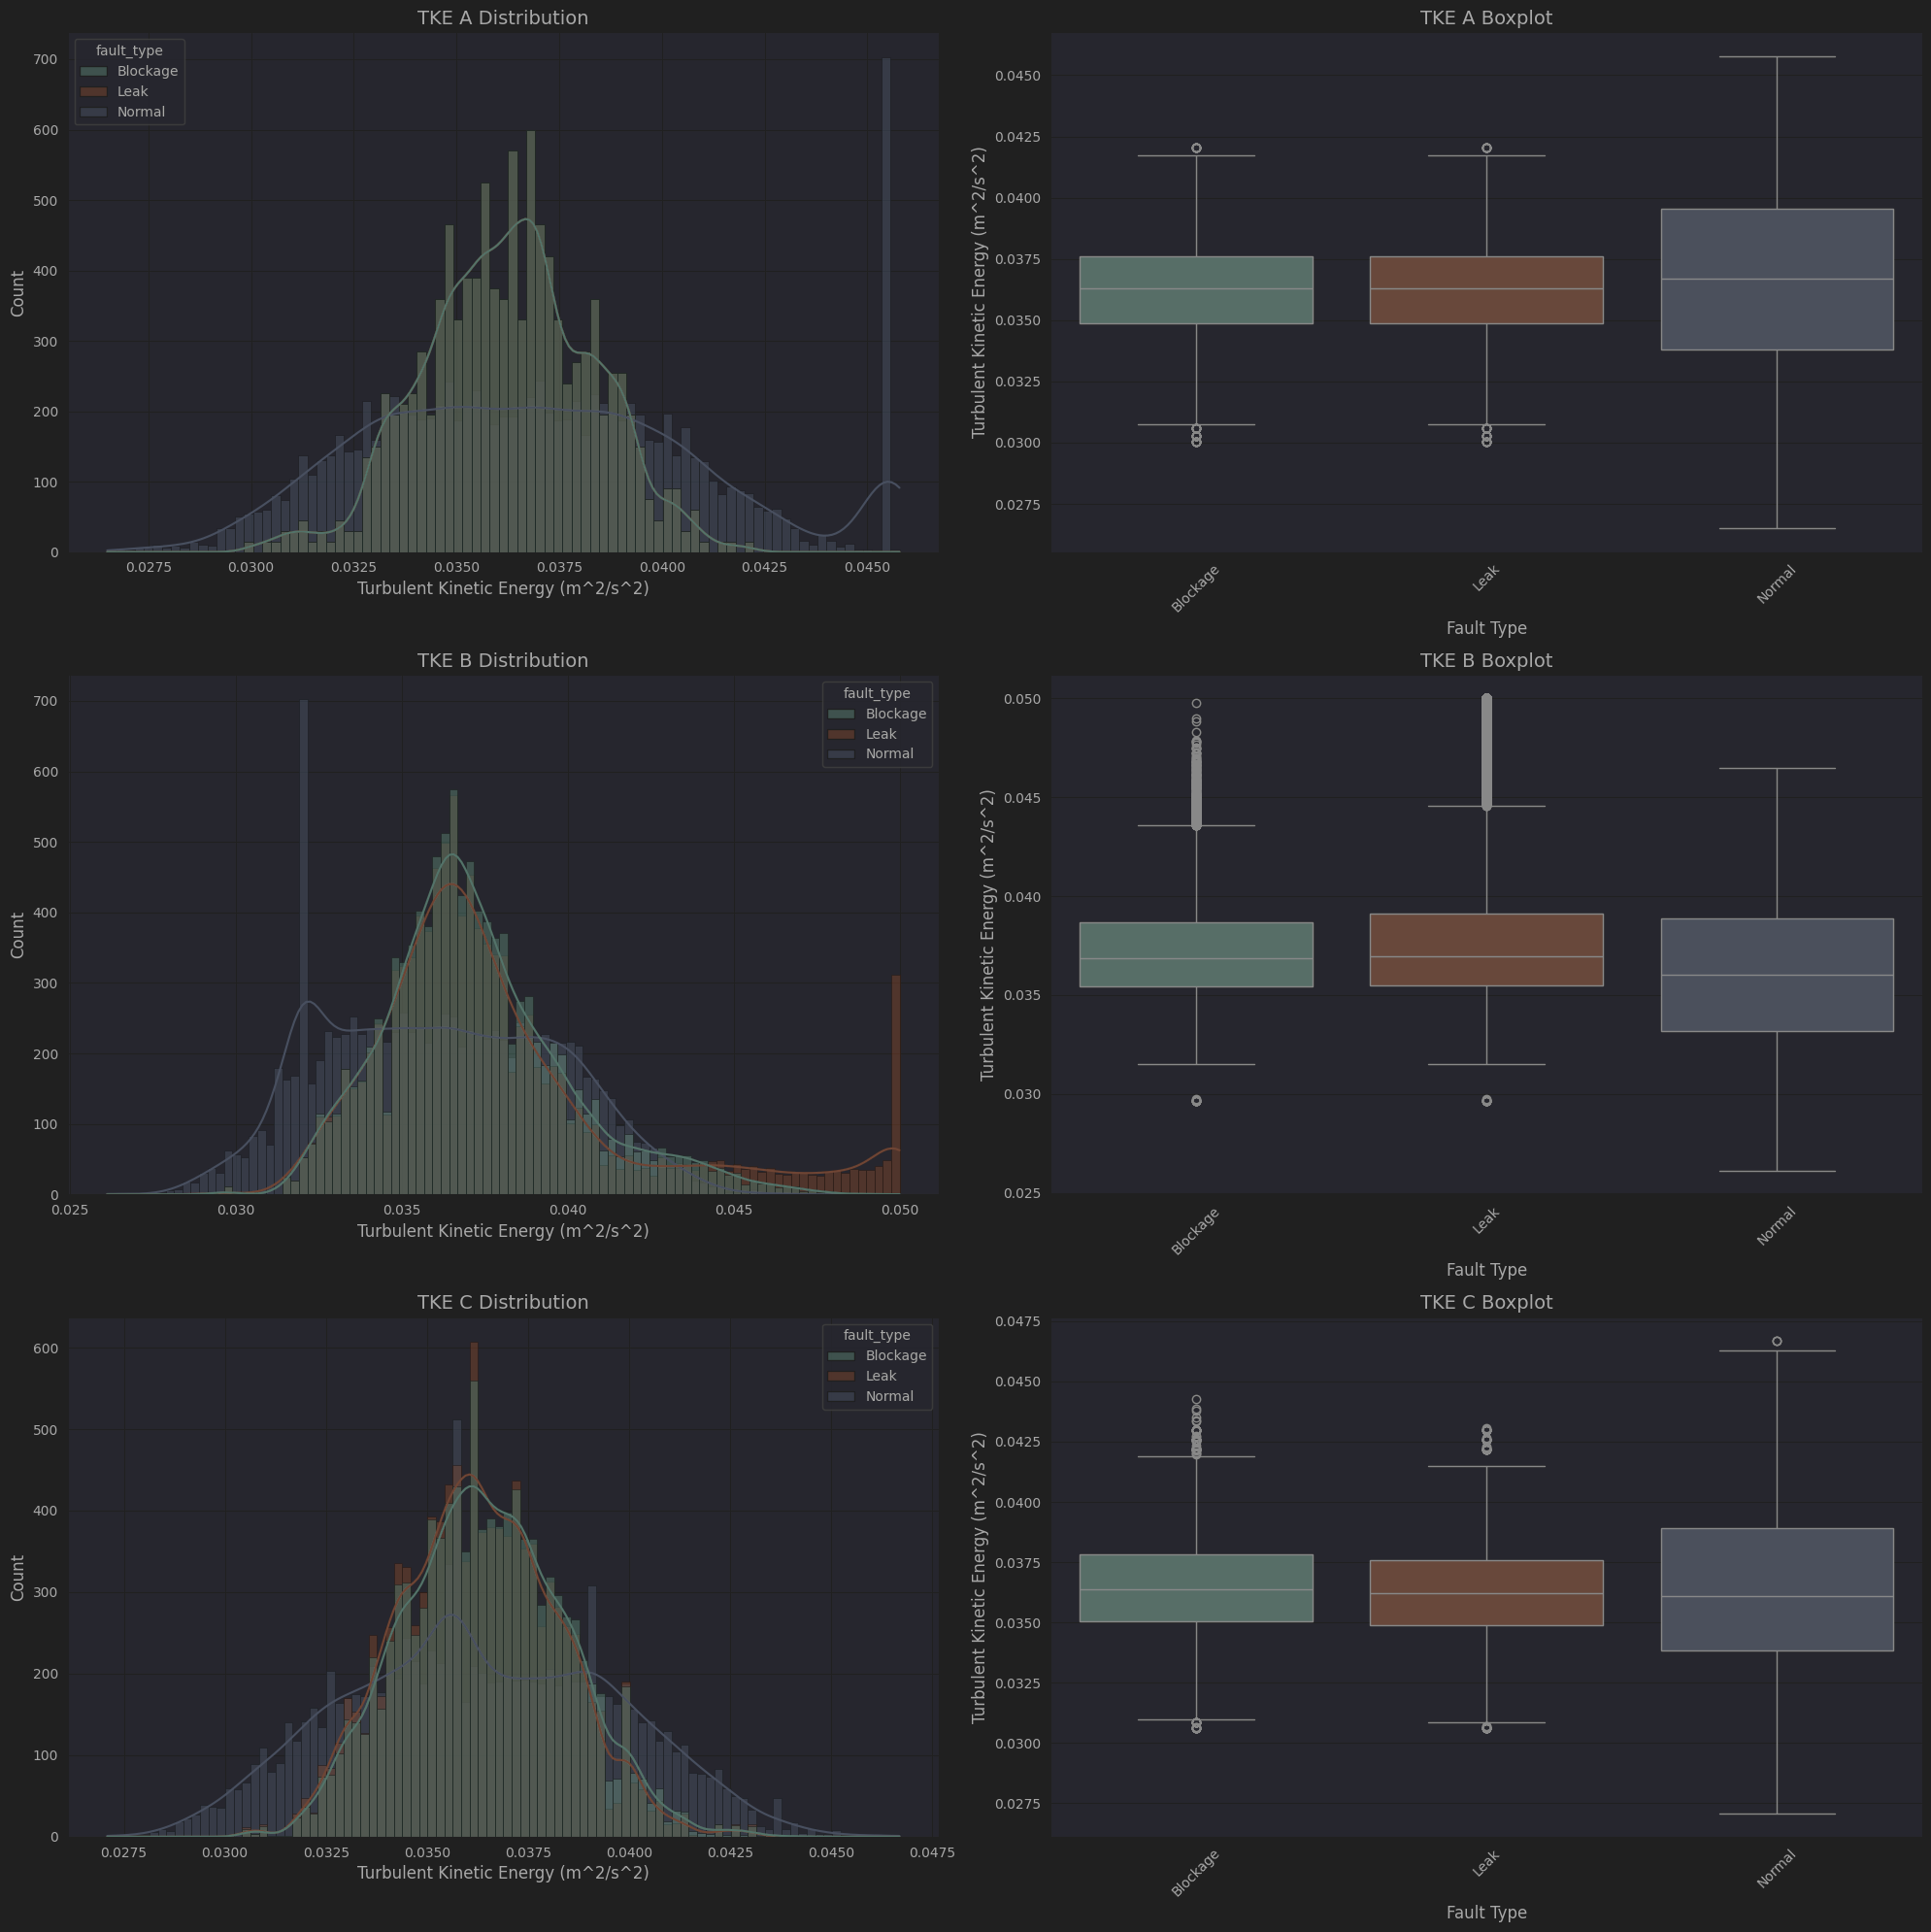

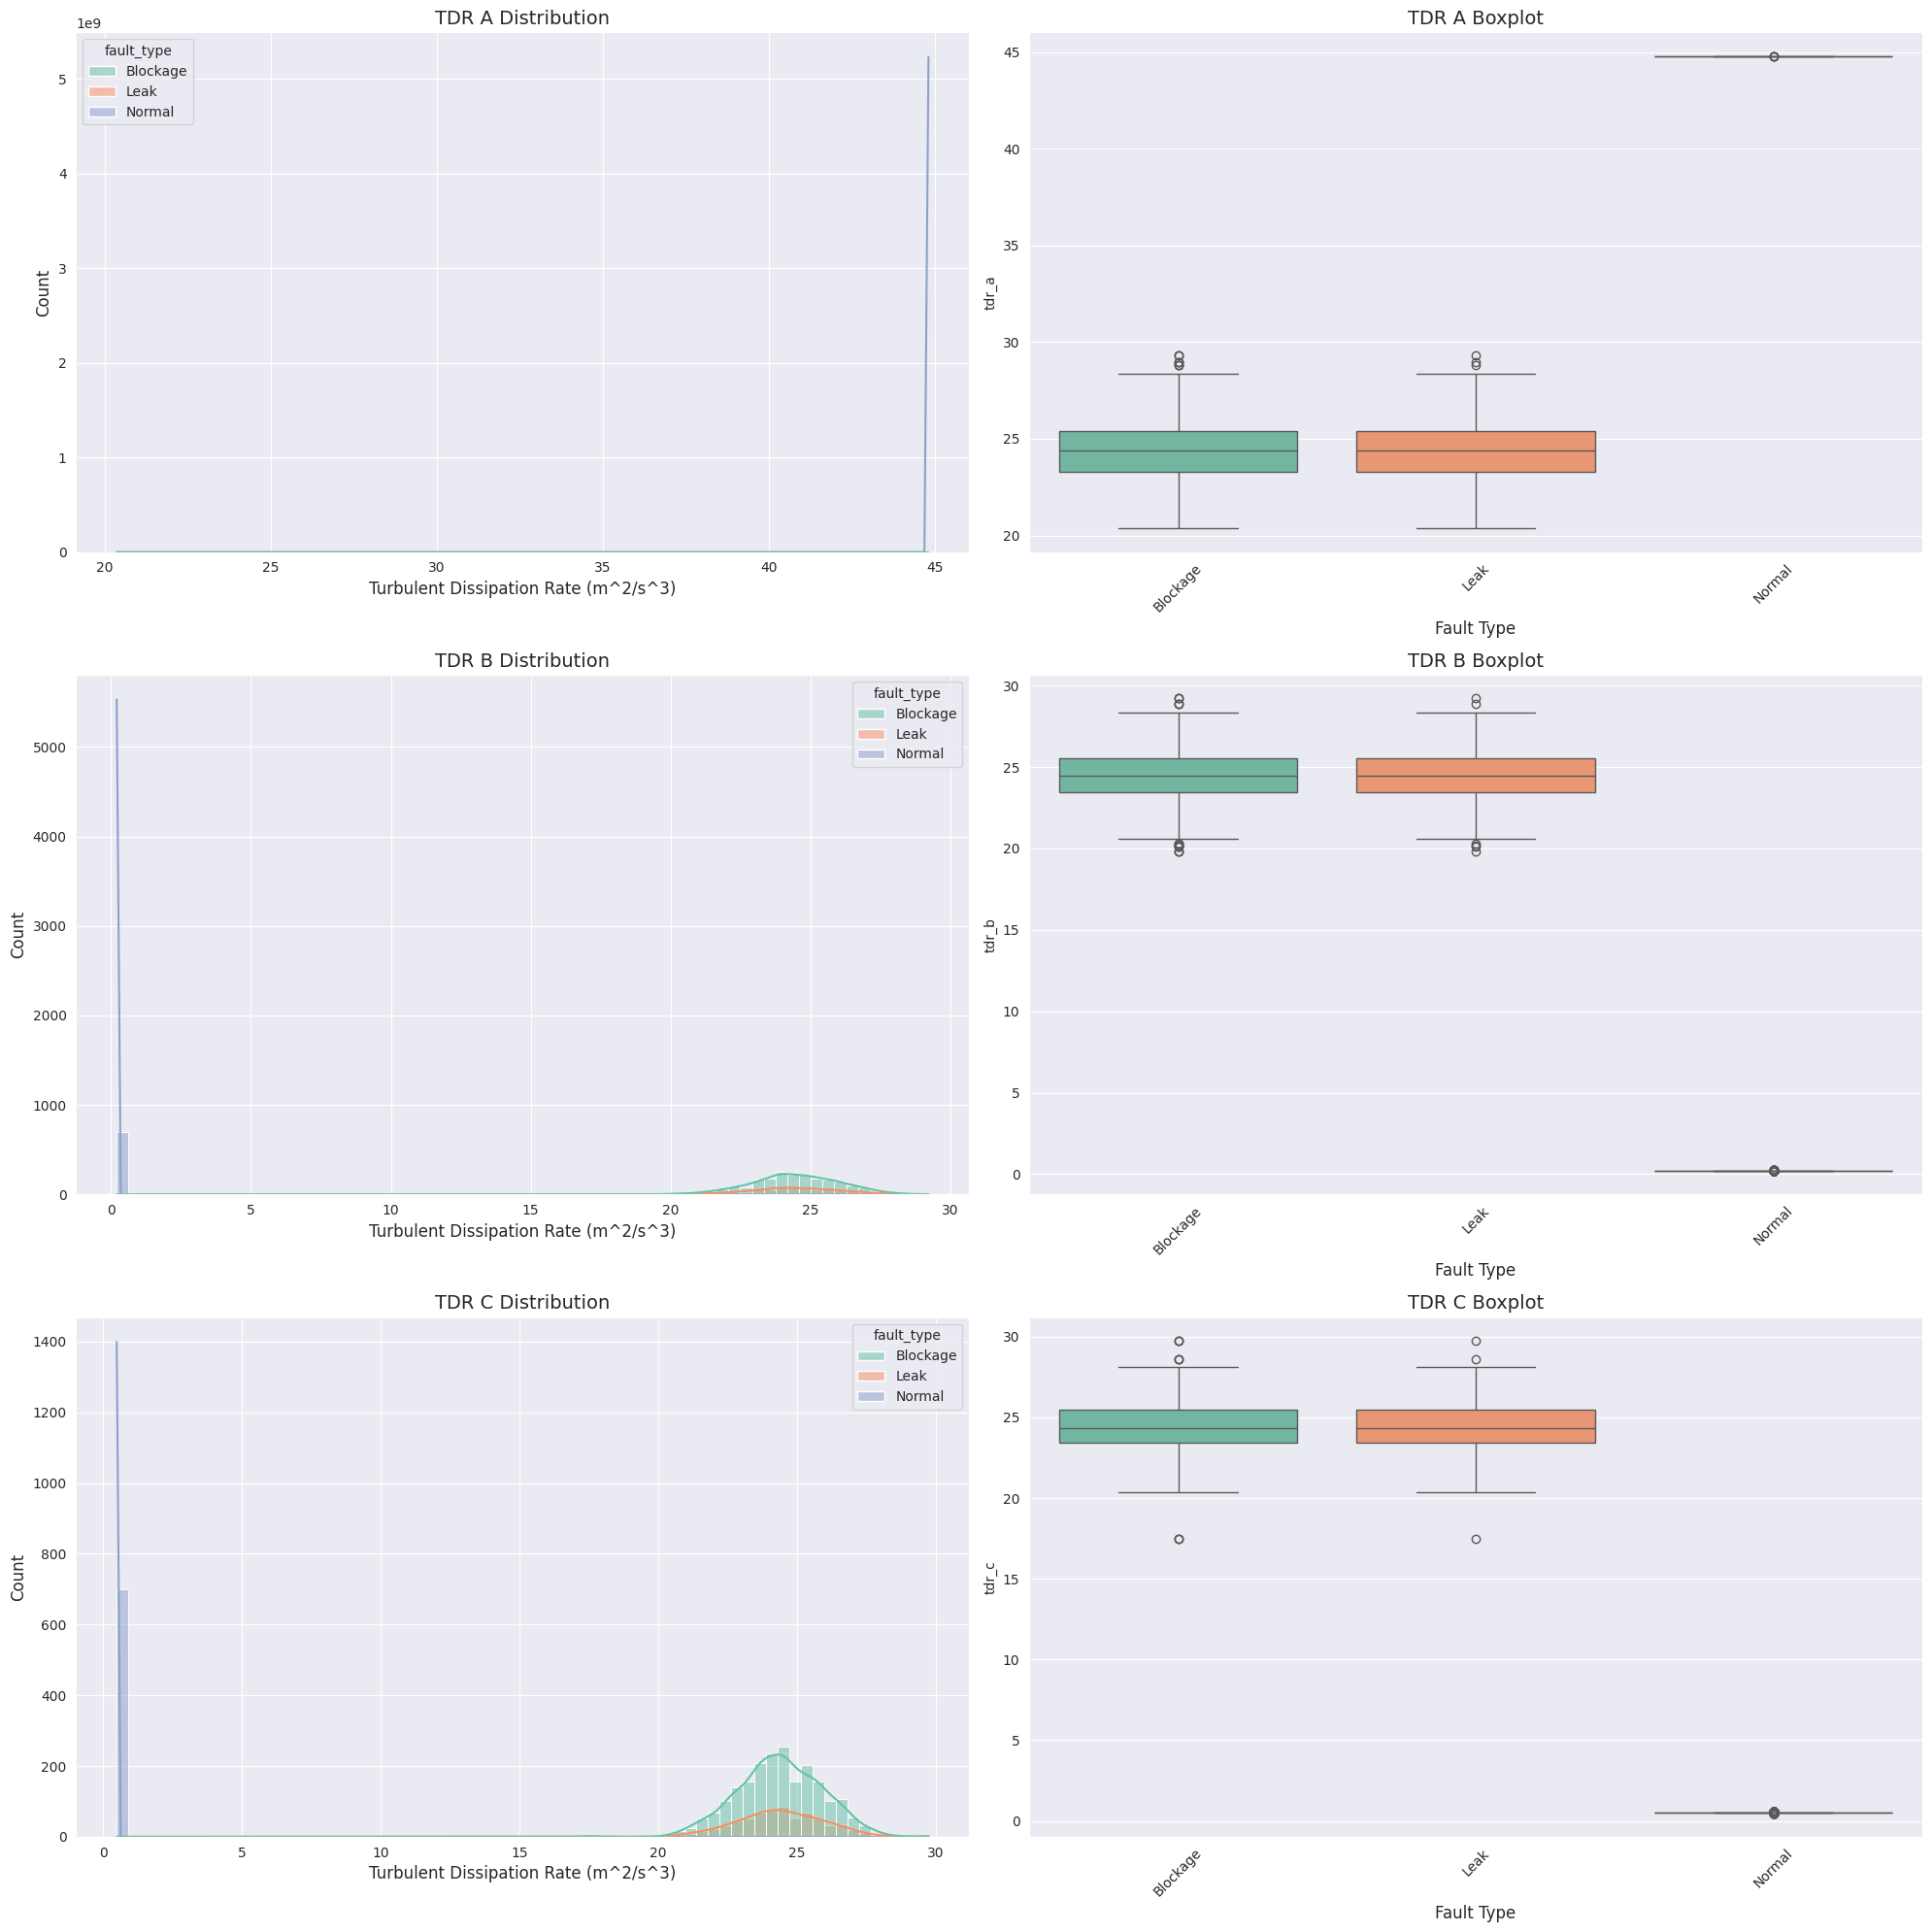

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))

for i, node in enumerate(["tdr_a", "tdr_b", "tdr_c"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').upper()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').upper()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Synthesized TDR Visualization Insights and Strategic Recommendations

### Node A
Blockage and Leak completely overlap, forming tight distributions around 20–29 m²/s³. Normal shows a wider spread with a longer right tail extending to approximately 45 m²/s³. The boxplot confirms this with Normal exhibiting a noticeably larger interquartile range. There is no separation between fault classes at Node A.

---

### Node B
Node B provides the most informative pattern. Blockage and Leak share a dominant peak around 20–25 m²/s³, but both exhibit a distinct right tail extending to 55–60 m²/s³. Normal is distributed more broadly and slightly shifted to the left, with a different spread profile.

A bimodal tendency is visible in the fault classes: the main body overlaps with Normal, while the high-TDR tail is primarily associated with fault conditions. The boxplots show nearly identical medians for Blockage and Leak, but significantly extended upper whiskers compared to Normal.

---

### Node C
All three classes converge into a sharp right-skewed distribution centered around 15–25 m²/s³. There is near-complete overlap across classes. Normal again shows a slightly wider base distribution, but no meaningful separation is present at this node.

---

## Physical Interpretation

The observed patterns are physically consistent. Turbulence dissipation rate should increase near fault locations due to accelerated energy cascade from larger to smaller eddies under disturbed flow conditions. The right-tail behavior observed at Node B for fault classes is therefore physically plausible.

However, because sensor locations are fixed and not always colocated with fault regions, the signal becomes diluted as it propagates through the system. This reduces class separability at most measurement points.

---

## Recommendations for Feature Engineering and Modeling

TDR shows slightly better discriminative behavior than TKE at Node B due to the presence of a fault-specific right tail. However, it remains a weak standalone feature for classification.

The right-skewed distributions observed at Nodes B and C suggest that a log transformation is appropriate. In particular, `log_tdr_b` may help compress extreme values and improve model sensitivity to the high-dissipation tail associated with fault conditions.

The wider spread observed in Normal at Node A reflects realistic CFD behavior, where turbulence dissipation varies naturally across pipe cross-sections. This variability is not equally represented in the synthetic fault distributions.

Like TKE, raw TDR should be retained initially but evaluated through feature importance analysis after engineering. If turbulence intensity (defined as √TKE normalized by velocity magnitude) is introduced, it may outperform both TKE and TDR individually and could render some raw turbulence features redundant.

### Wall Shear Distributions Per Class

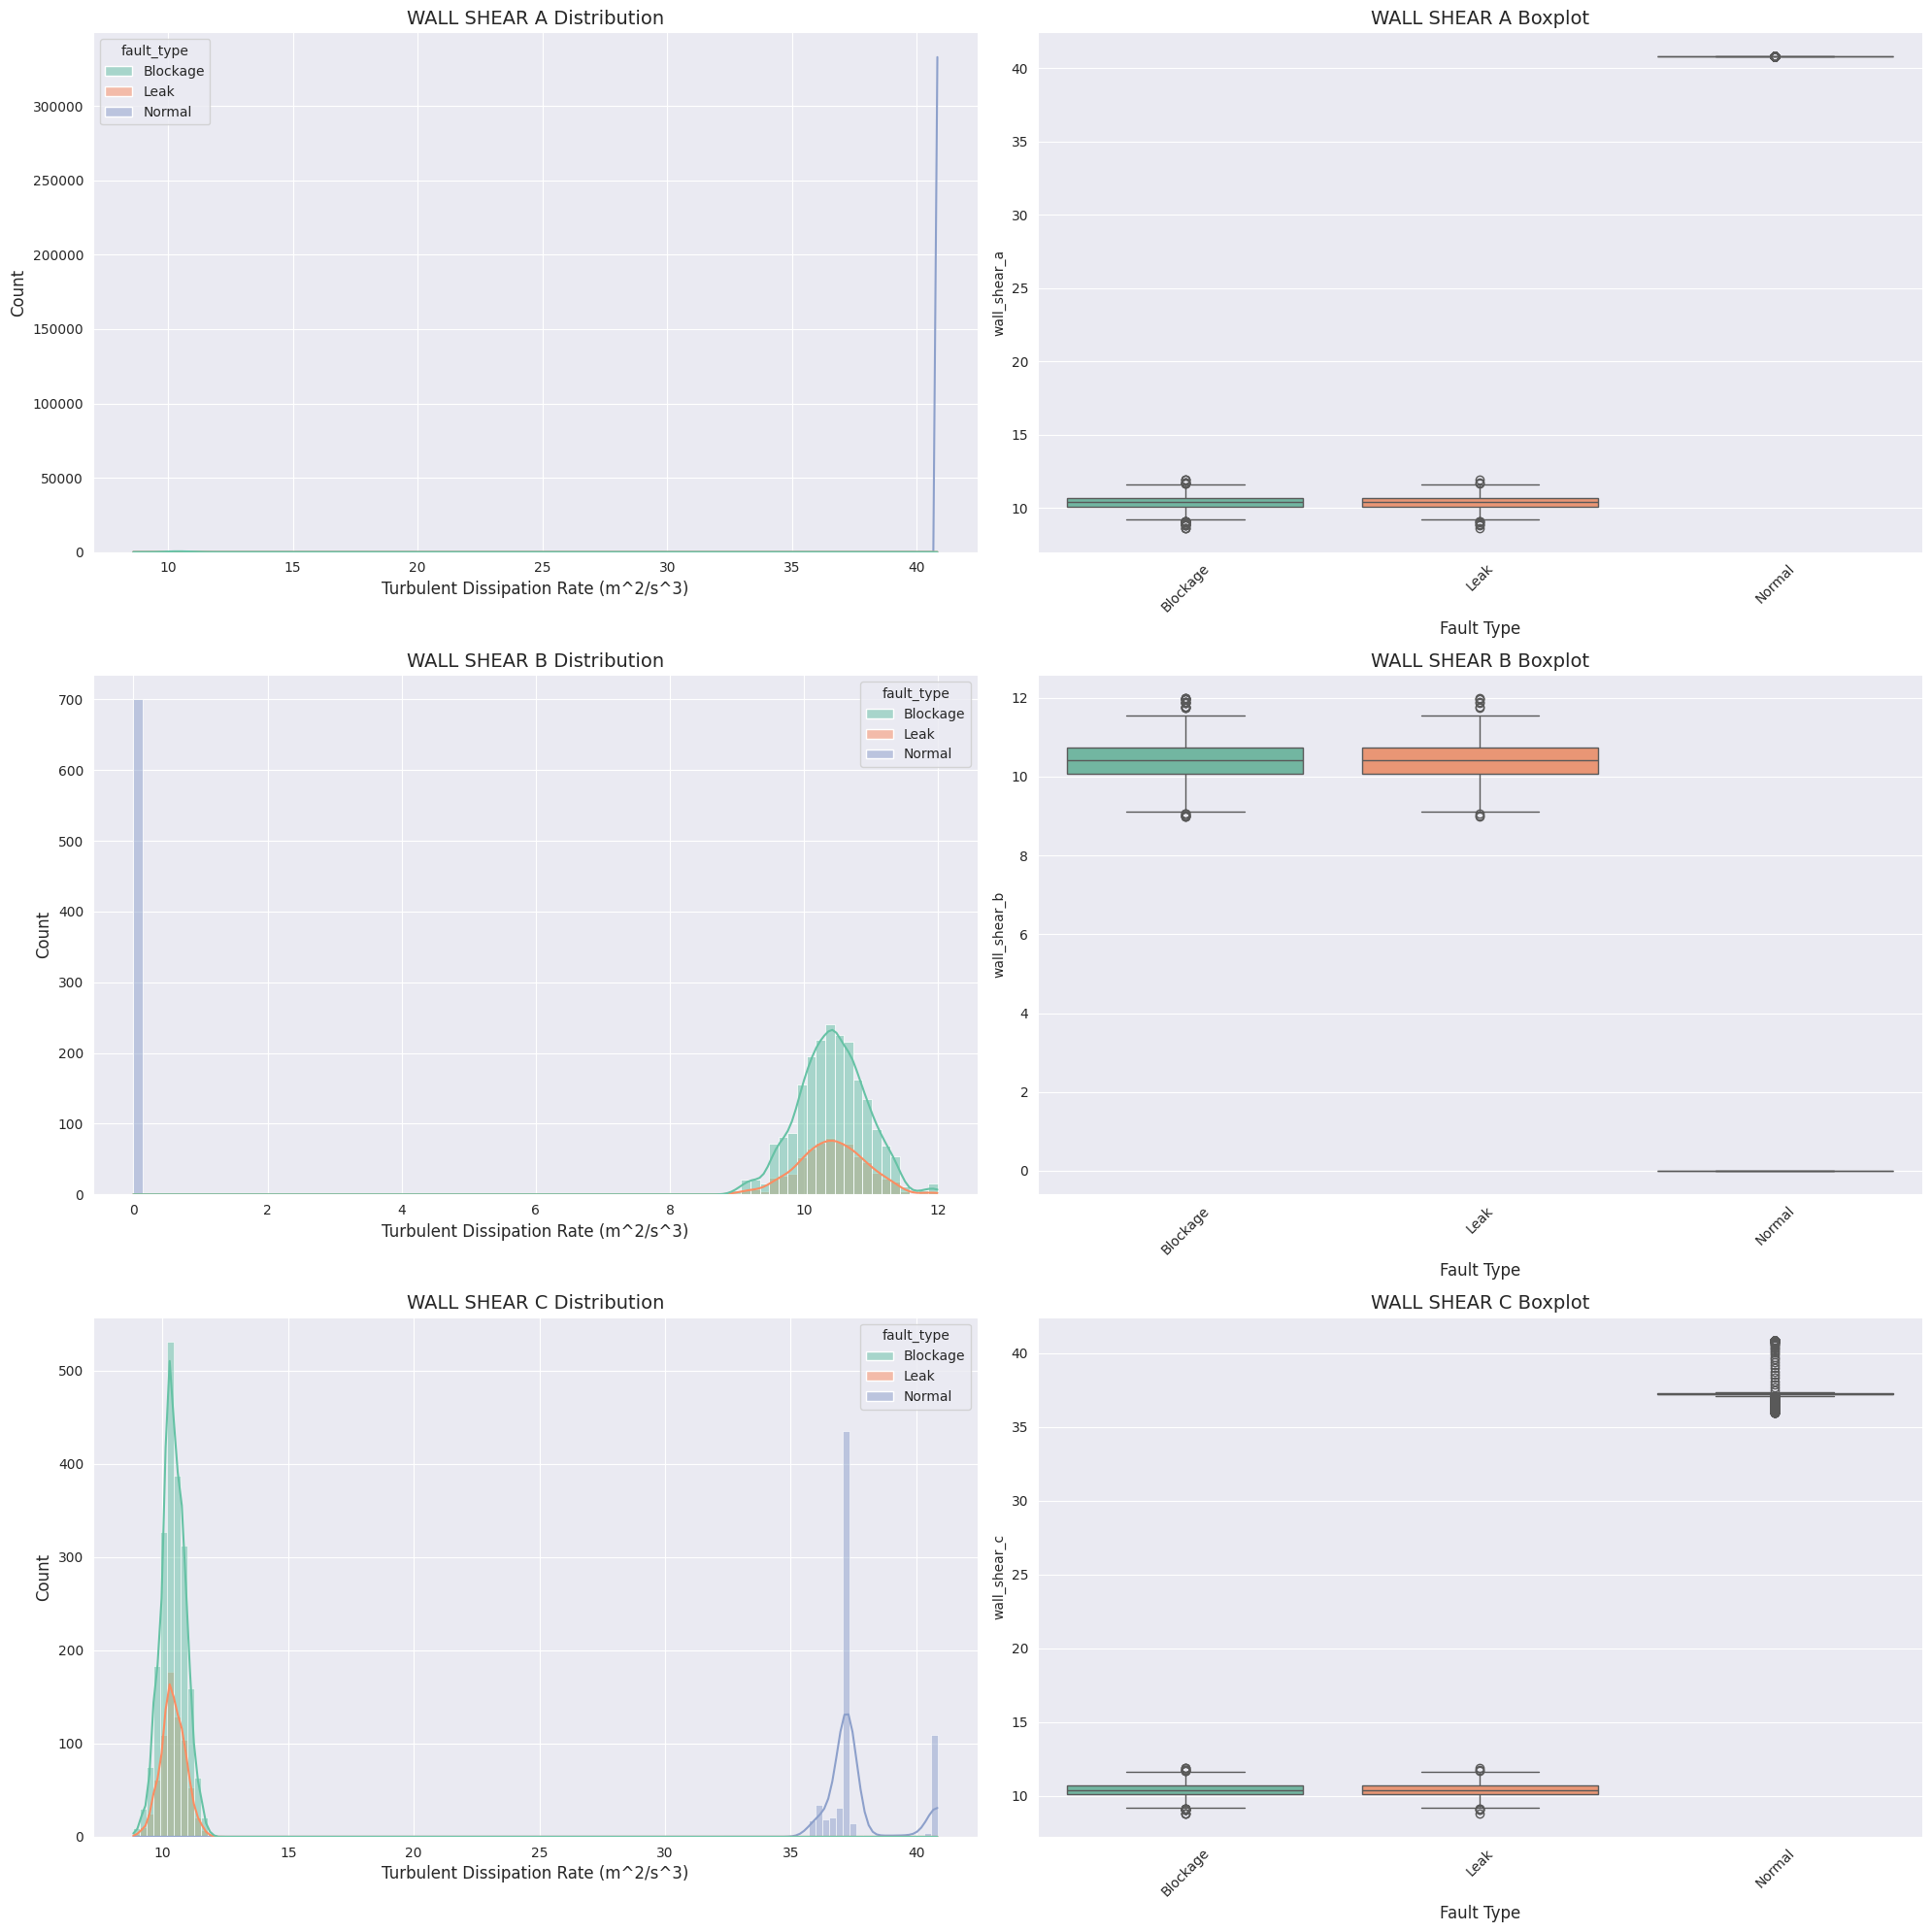

In [44]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
for i, node in enumerate(["wall_shear_a", "wall_shear_b", "wall_shear_c"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').upper()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').upper()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Wall Shear Distribution Analysis and Recommendations

### Node A
All three classes form an almost identical sharp peak around 10 Pa, with Blockage and Leak overlapping completely. Normal shows a single extreme outlier near 40 Pa in the boxplot. This reflects a real CFD node at the pipe wall where shear is naturally high. There is no meaningful class separation at this node.

---

### Node B
This is the most informative wall shear plot. Normal displays a broad distribution shifted to the left, extending down to values near 0 Pa. Blockage and Leak share a tighter peak around 10–11 Pa, with right tails reaching approximately 18–19 Pa.

The Normal distribution reaching 0.0 is a known data artifact. In real CFD data, pipe center nodes have zero wall shear. The boxplot shows Normal has a lower minimum than both fault classes. This creates the only visible separation signal, but it is driven by the artifact rather than true physical differences.

---

### Node C
Blockage and Leak again overlap completely in a sharp peak around 10 Pa. Normal shows a wider spread with an extreme outlier near 40 Pa, similar to Node A. There is no usable separation signal at this node.

---

## Physical Interpretation

The patterns are only partially consistent with physical expectations. Wall shear should increase near fault locations due to disturbed flow and higher local velocity gradients. The right-tail behavior at Node B for fault classes aligns with this expectation.

However, the observed separation between Normal and fault classes at Node B is largely influenced by the synthetic data generation process rather than true physical variation. This limits the reliability of wall shear as a discriminative feature.

---

## Recommendations for Feature Engineering and Modeling

Wall shear is a weak standalone discriminator across all nodes. The limited separation observed at Node B is partly due to a known artifact in the dataset. The synthetic fault data imposes a minimum wall shear floor above 8 Pa, while real CFD Normal data correctly includes values down to 0 Pa at pipe center nodes.

This imbalance means models trained on raw wall shear may learn to exploit this artifact instead of capturing genuine physical relationships.

A better approach is to engineer a normalized feature such as the shear-velocity ratio:

- `wall_shear / velocity_magnitude` at each node

This transformation removes magnitude bias and retains the physically meaningful relationship between surface friction and flow speed.

Raw wall shear features should be retained initially but carefully evaluated during feature importance analysis. If the model assigns high importance to wall shear, it is important to verify whether this importance persists after correcting or accounting for the artifact floor.

### Tailings VOF Distributions Per Class


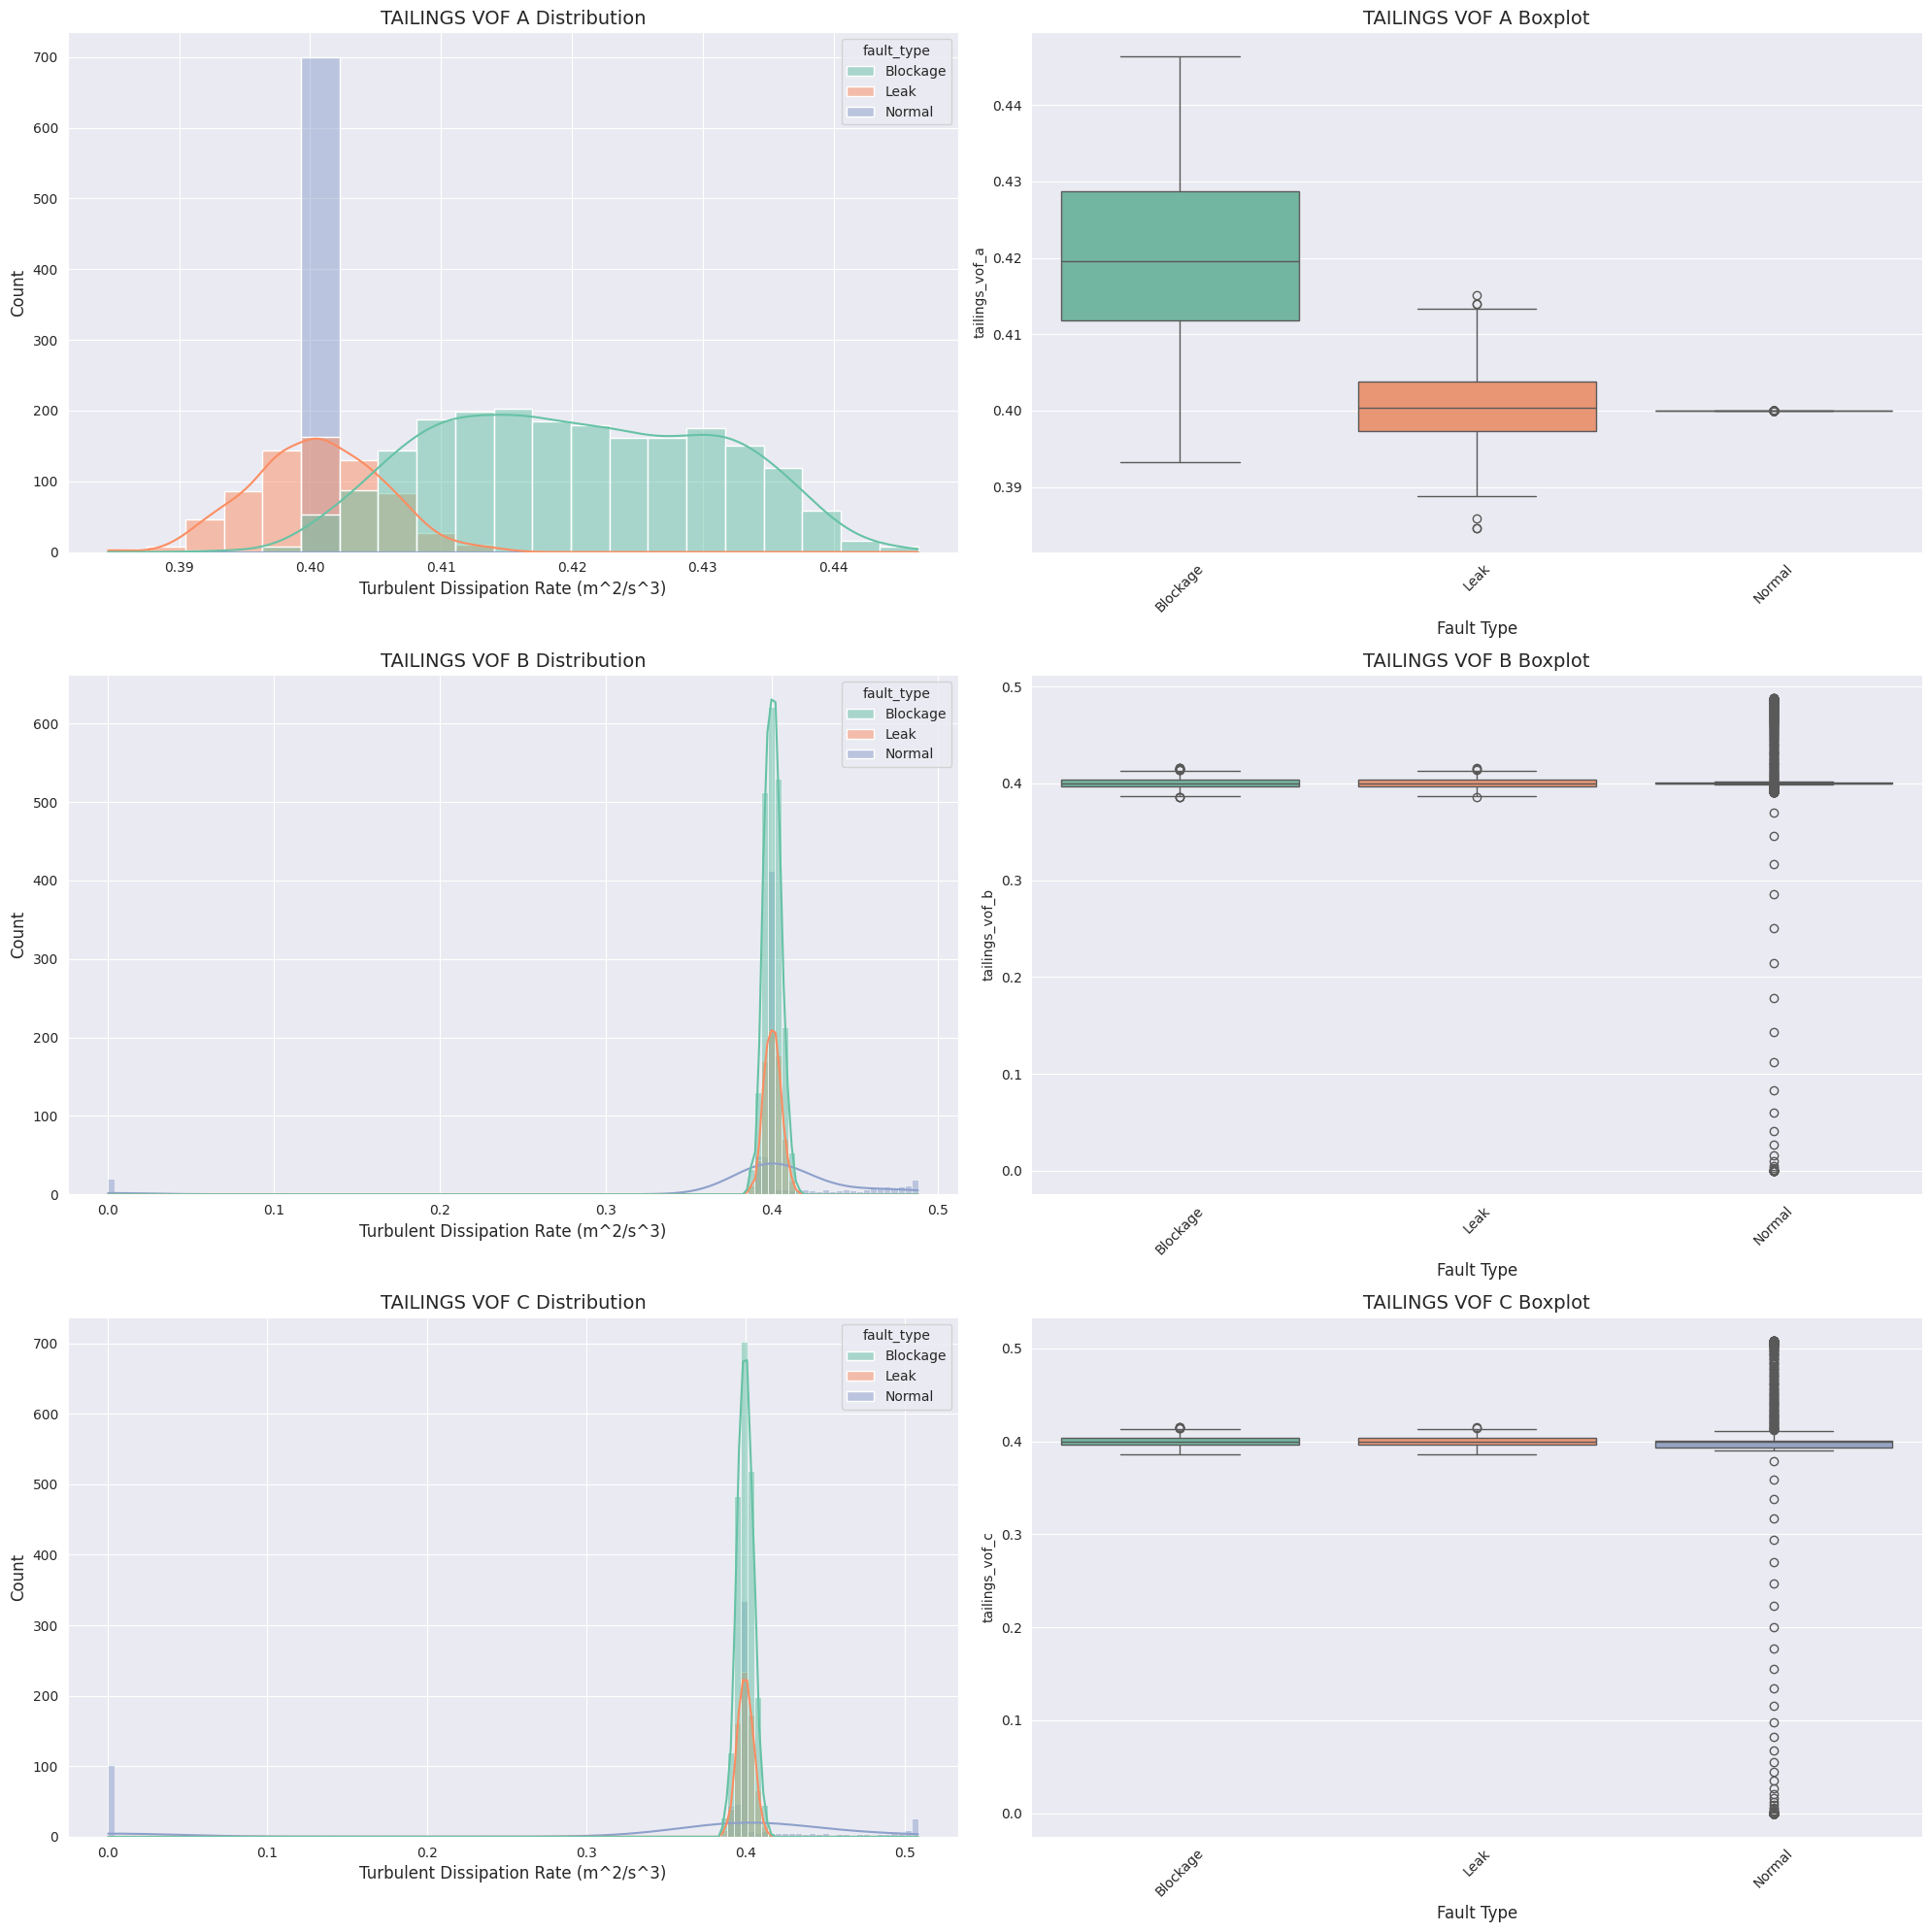

In [45]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
for i, node in enumerate(["tailings_vof_a", "tailings_vof_b", "tailings_vof_c"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').upper()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').upper()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Tailings VOF Distribution Analysis and Recommendations

### Node A
Blockage shows a clear bimodal distribution with peaks around 0.38 and 0.405, positioned slightly to the right of Normal and Leak. Leak and Normal overlap heavily in the main peak, but Normal has a noticeably wider spread extending in both directions. The boxplot confirms that Blockage has a tighter interquartile range and is shifted slightly higher. This aligns with the expected physical behavior where solids accumulate upstream of a blockage. Node A is the only location where VOF provides meaningful class separation.

---

### Node B
All three classes converge into a single sharp peak around 0.40 in the KDE, suggesting strong overlap. However, the boxplot reveals a different pattern. Normal contains a large number of extreme outliers extending down to near 0.0. These represent real CFD nodes where tailings concentration drops to almost zero, indicating clear fluid regions in the simulation.

Blockage and Leak do not exhibit these outliers, with their values remaining above approximately 0.35. This creates an apparent separation, but it is driven by distribution tails rather than the central tendency.

---

### Node C
Node C mirrors the behavior observed at Node B. The KDE shows near-complete overlap across all classes, but the boxplot again highlights extreme low-value outliers in the Normal class. Fault classes remain tightly bounded above roughly 0.36.

---

## Physical Interpretation

The patterns observed are physically consistent. The bimodal distribution at Node A for Blockage reflects upstream solid accumulation, which is expected in obstructed flow conditions.

The near-zero outliers in the Normal class at Nodes B and C are also physically valid. They correspond to regions in the CFD simulation where tailings concentration is minimal or absent. The tighter distributions seen in the fault classes are more reflective of the synthetic data generation process rather than natural variability.

---

## Recommendations for Feature Engineering and Modeling

Tailings VOF at Node A is the only VOF feature with clear discriminative value, primarily due to the bimodal structure associated with Blockage.

VOF at Nodes B and C shows heavy overlap in the main distribution and is unlikely to contribute significantly as standalone features.

The presence of extreme low-value outliers in the Normal class at Nodes B and C introduces strong skewness. This can negatively affect standard scaling, as these values will shift the mean downward and inflate the standard deviation. As a result, normalization may become less effective for the fault classes, which do not contain similar low values.

To address this:

- Use robust scaling based on median and interquartile range instead of mean and standard deviation
- Alternatively, apply a lower-bound clipping strategy before scaling

For feature engineering, a spatial gradient feature is recommended:

- `tailings_vof_a - tailings_vof_c`

This captures upstream accumulation effects associated with Blockage and is less sensitive to extreme outliers at individual nodes.

Raw VOF features should be retained initially but evaluated alongside engineered features to determine their final contribution to model performance.

###  Derived Feature Distributions Per Class


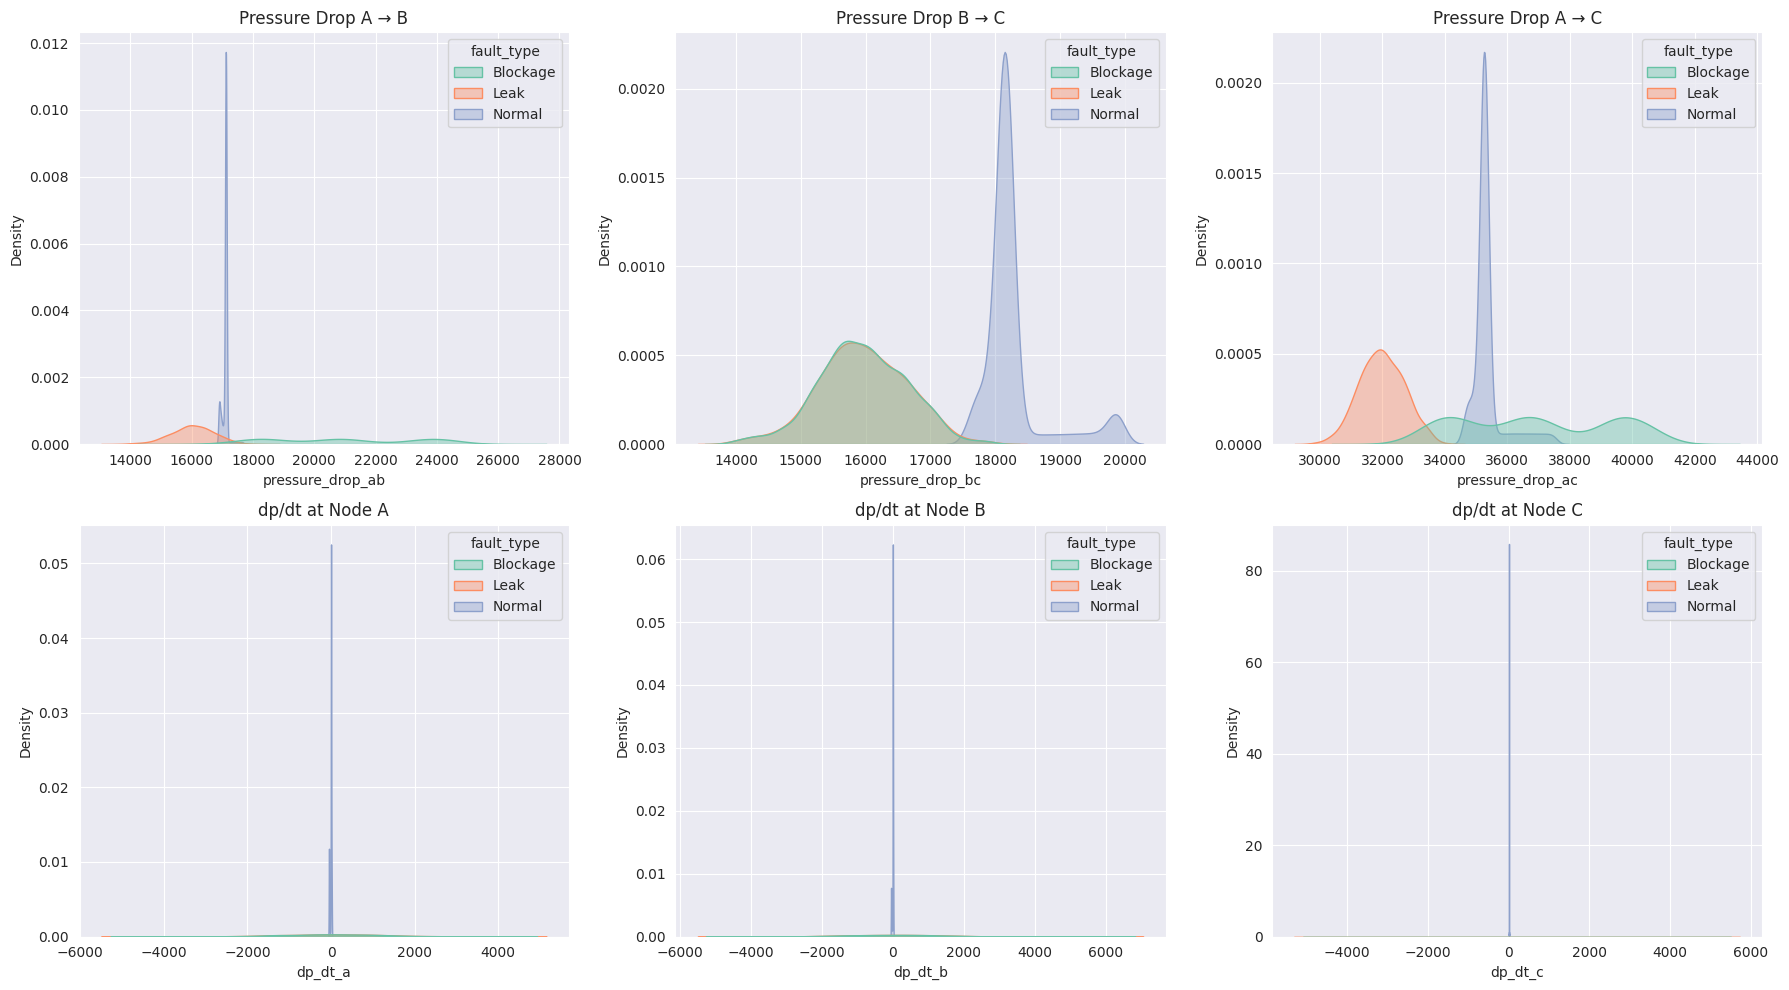

In [46]:
# Define features and titles
features = [
    "pressure_drop_ab",
    "pressure_drop_bc",
    "pressure_drop_ac",
    "dp_dt_a",
    "dp_dt_b",
    "dp_dt_c"
]

titles = [
    "Pressure Drop A → B",
    "Pressure Drop B → C",
    "Pressure Drop A → C",
    "dp/dt at Node A",
    "dp/dt at Node B",
    "dp/dt at Node C"
]

# Create figure (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot KDEs
for i, (feature, title) in enumerate(zip(features, titles)):
    sns.kdeplot(
        data=df,
        x=feature,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i],
        palette="Set2"
    )

    axes[i].set_title(title)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

## Pressure Drop and dp/dt Analysis with Recommendations

### Pressure Drop A to B
Leak and Normal form nearly identical tight distributions centered around 15,000 to 16,000 Pa. Blockage, however, shows a much broader distribution that is shifted left and extends into negative values down to approximately -10,000 Pa.

A negative pressure drop indicates that pressure at Node B exceeds pressure at Node A. This reflects a back pressure effect caused by blockage, where the obstruction elevates pressure at the midpoint above upstream levels. This creates strong separation for Blockage, while Leak and Normal remain indistinguishable.

---

### Pressure Drop B to C
This is the most informative feature observed in the entire analysis. Blockage is clearly separated with a right-shifted distribution peaking around 19,000 to 25,000 Pa and extending up to 40,000 Pa.

Leak and Normal overlap tightly around 16,000 Pa with minimal spread. The separation arises because blockage simultaneously increases pressure at Node B and reduces pressure at Node C, producing an unusually large pressure drop between these points.

This makes `pressure_drop_bc` the strongest single feature for identifying Blockage.

---

### Pressure Drop A to C
Blockage shows a broader distribution shifted slightly to the right, centered around 33,000 to 36,000 Pa. Leak and Normal again overlap in a tight peak around 32,000 Pa.

This feature provides moderate separation for Blockage but is weaker compared to the B to C drop. Leak and Normal remain indistinguishable.

---

### dp/dt at Nodes A, B, and C
All three classes show complete overlap across all nodes. The distributions are centered around zero with symmetric spread and no visible separation.

This confirms that dp/dt carries no discriminative information in this dataset.

---

## Recommendations for Feature Selection and Modeling

The pressure drop features establish a clear hierarchy of importance:

- `pressure_drop_bc` is the most informative feature for Blockage detection. It captures the combined effect of elevated midpoint pressure and reduced downstream pressure, producing a uniquely large drop.

- `pressure_drop_ab` adds complementary value by capturing cases where back pressure reverses the expected gradient, resulting in negative drops.

- `pressure_drop_ac` is largely redundant because it is effectively the sum of the other two and does not provide independent information.

For dp/dt features:

- All dp/dt columns should be removed from the feature set.
- The identical distributions across all classes indicate no useful signal for classification.
- This is consistent with the data generation process, where pressure values are effectively stationary at each timestep.

Temporal behavior will instead be captured by the LSTM model through its sliding window of sequential inputs, making manually engineered rate-of-change features unnecessary and potentially harmful due to added noise.

---

## Summary

Pressure drop features, particularly `pressure_drop_bc`, provide the strongest signals for distinguishing Blockage. In contrast, dp/dt features offer no meaningful contribution and should be excluded to simplify the model and improve learning efficiency.

### Node Comparison within each class

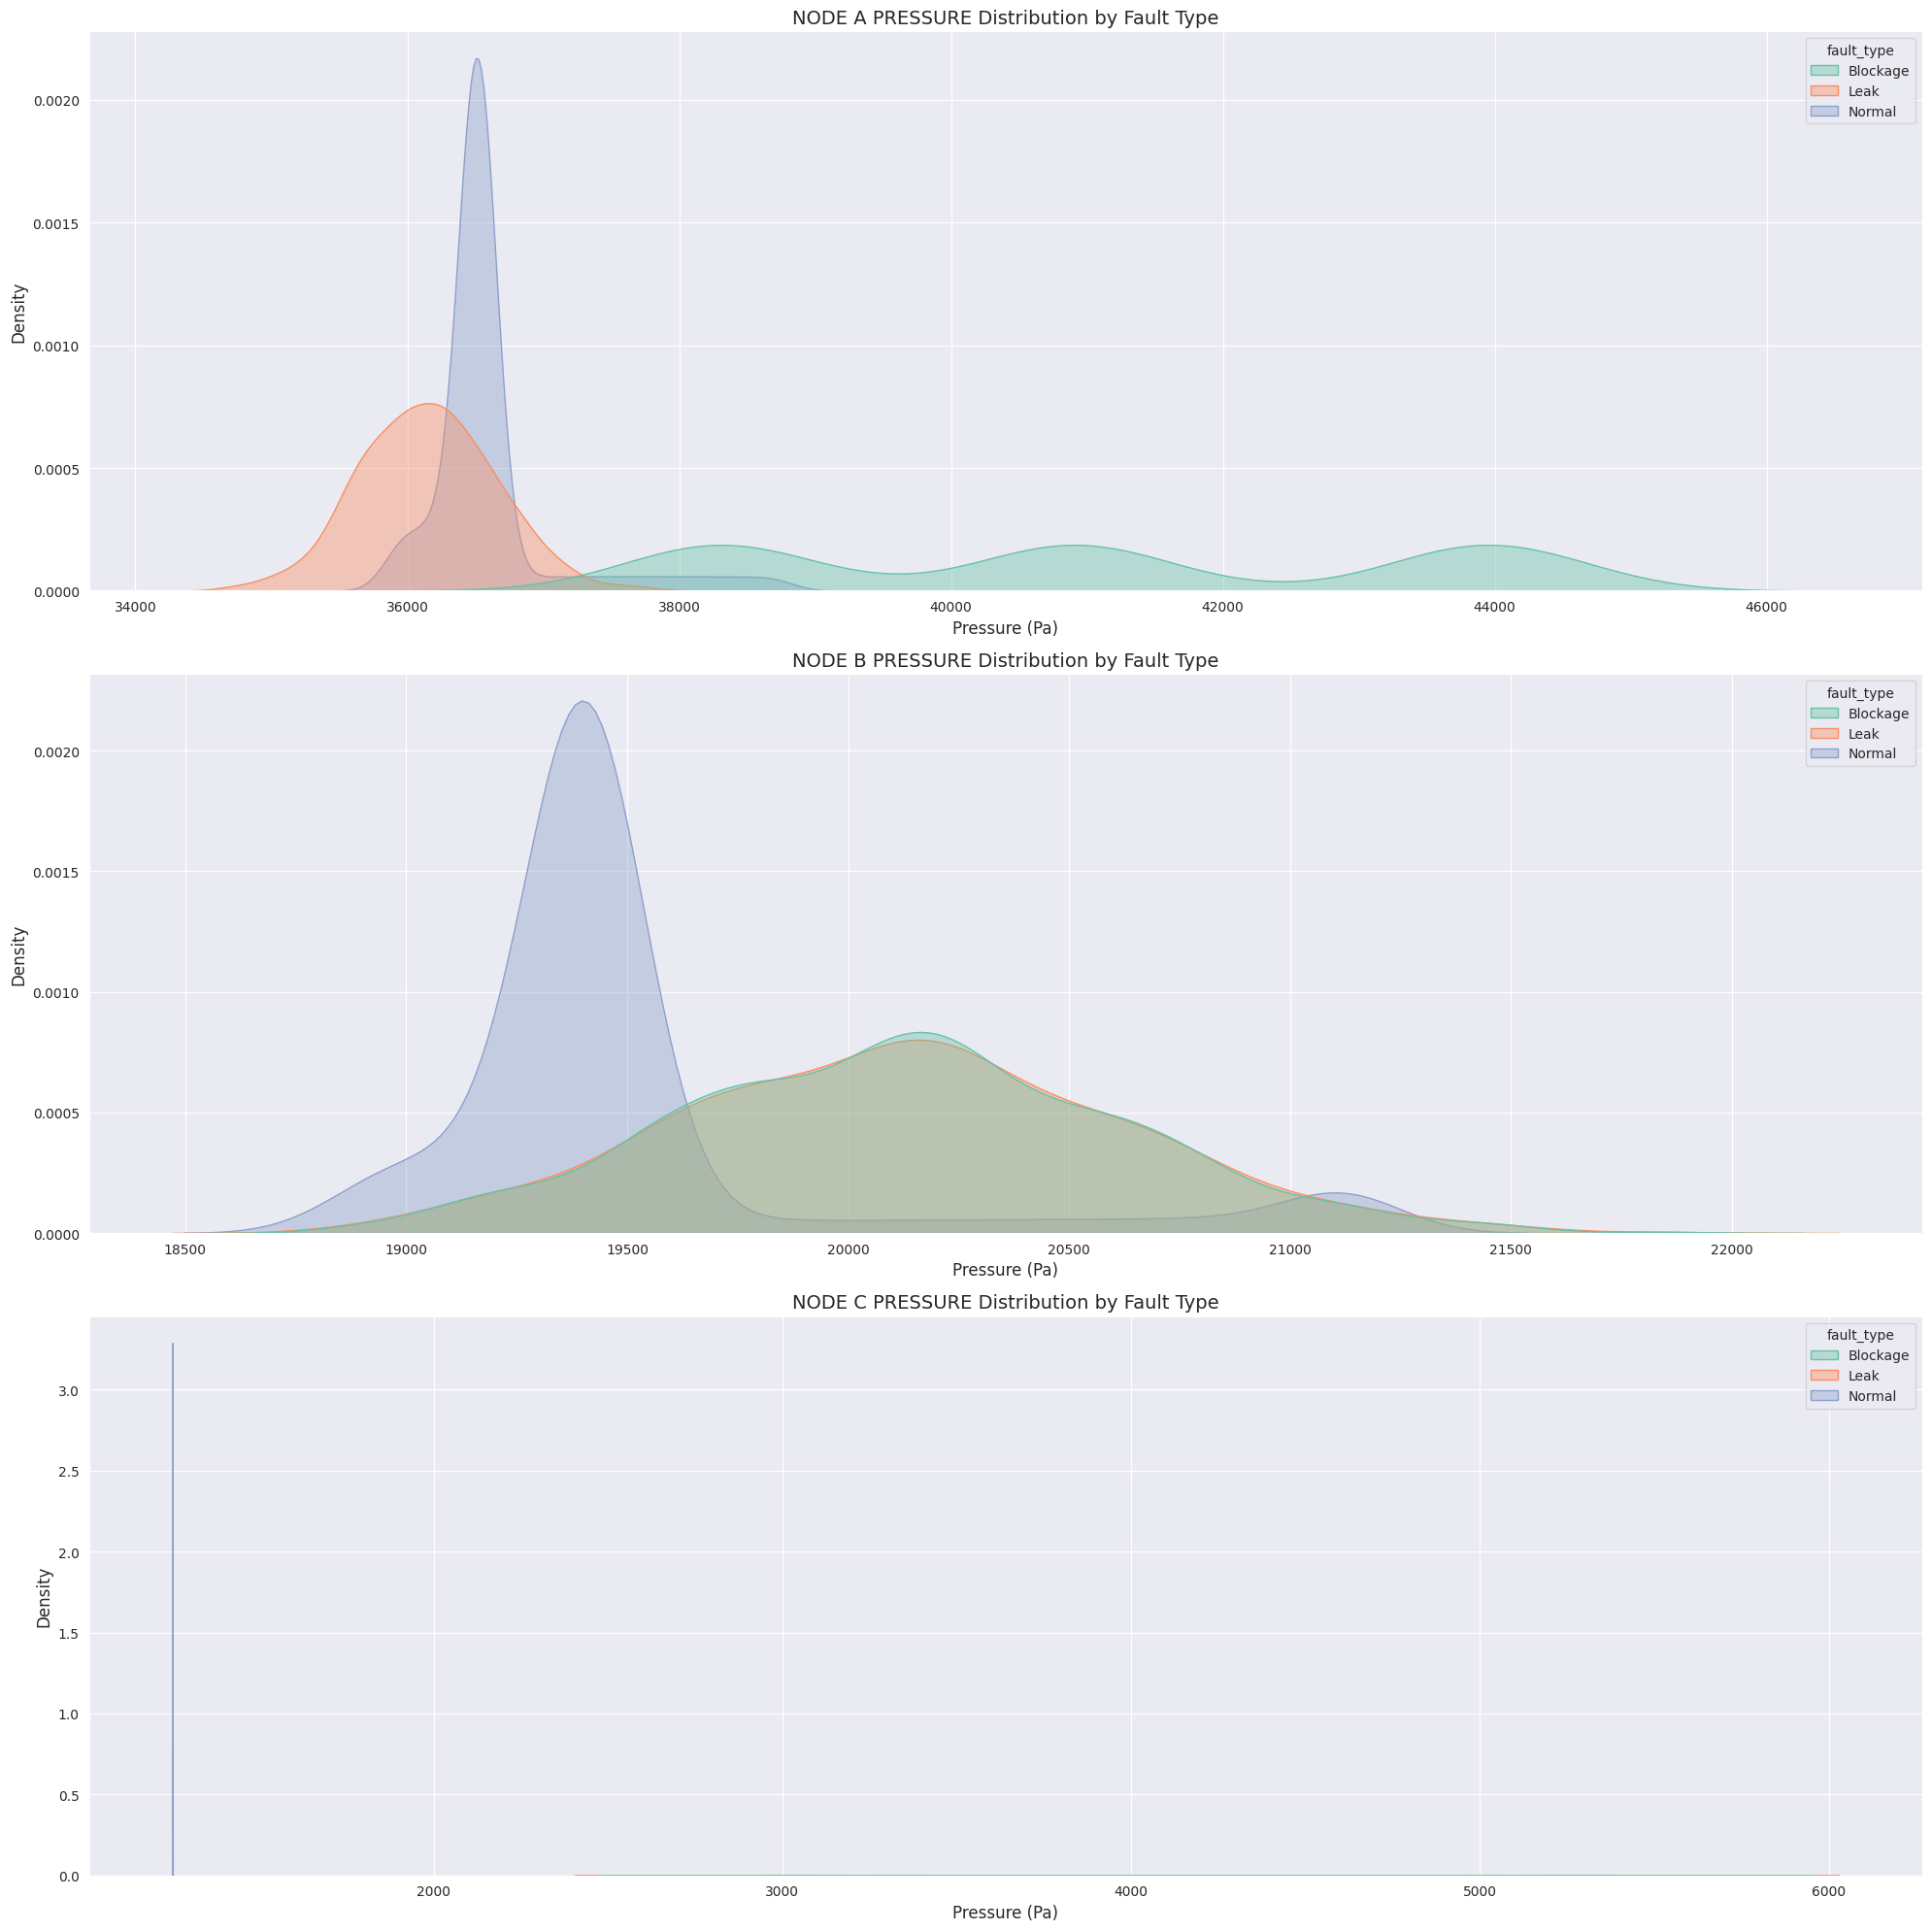

In [47]:
fig, axes = plt.subplots(3,1, figsize=(20, 20))

for i, node in enumerate(["node_a_pressure", "node_b_pressure", "node_c_pressure"]):
    sns.kdeplot(
        data=df,
        x=node,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i],
        palette="Set2"
    )

    axes[i].set_title(f"{node.replace('_', ' ').upper()} Distribution by Fault Type", fontsize=14)
    axes[i].set_xlabel("Pressure (Pa)", fontsize=12)
    axes[i].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()

###  Leak vs Blockage Discrimination

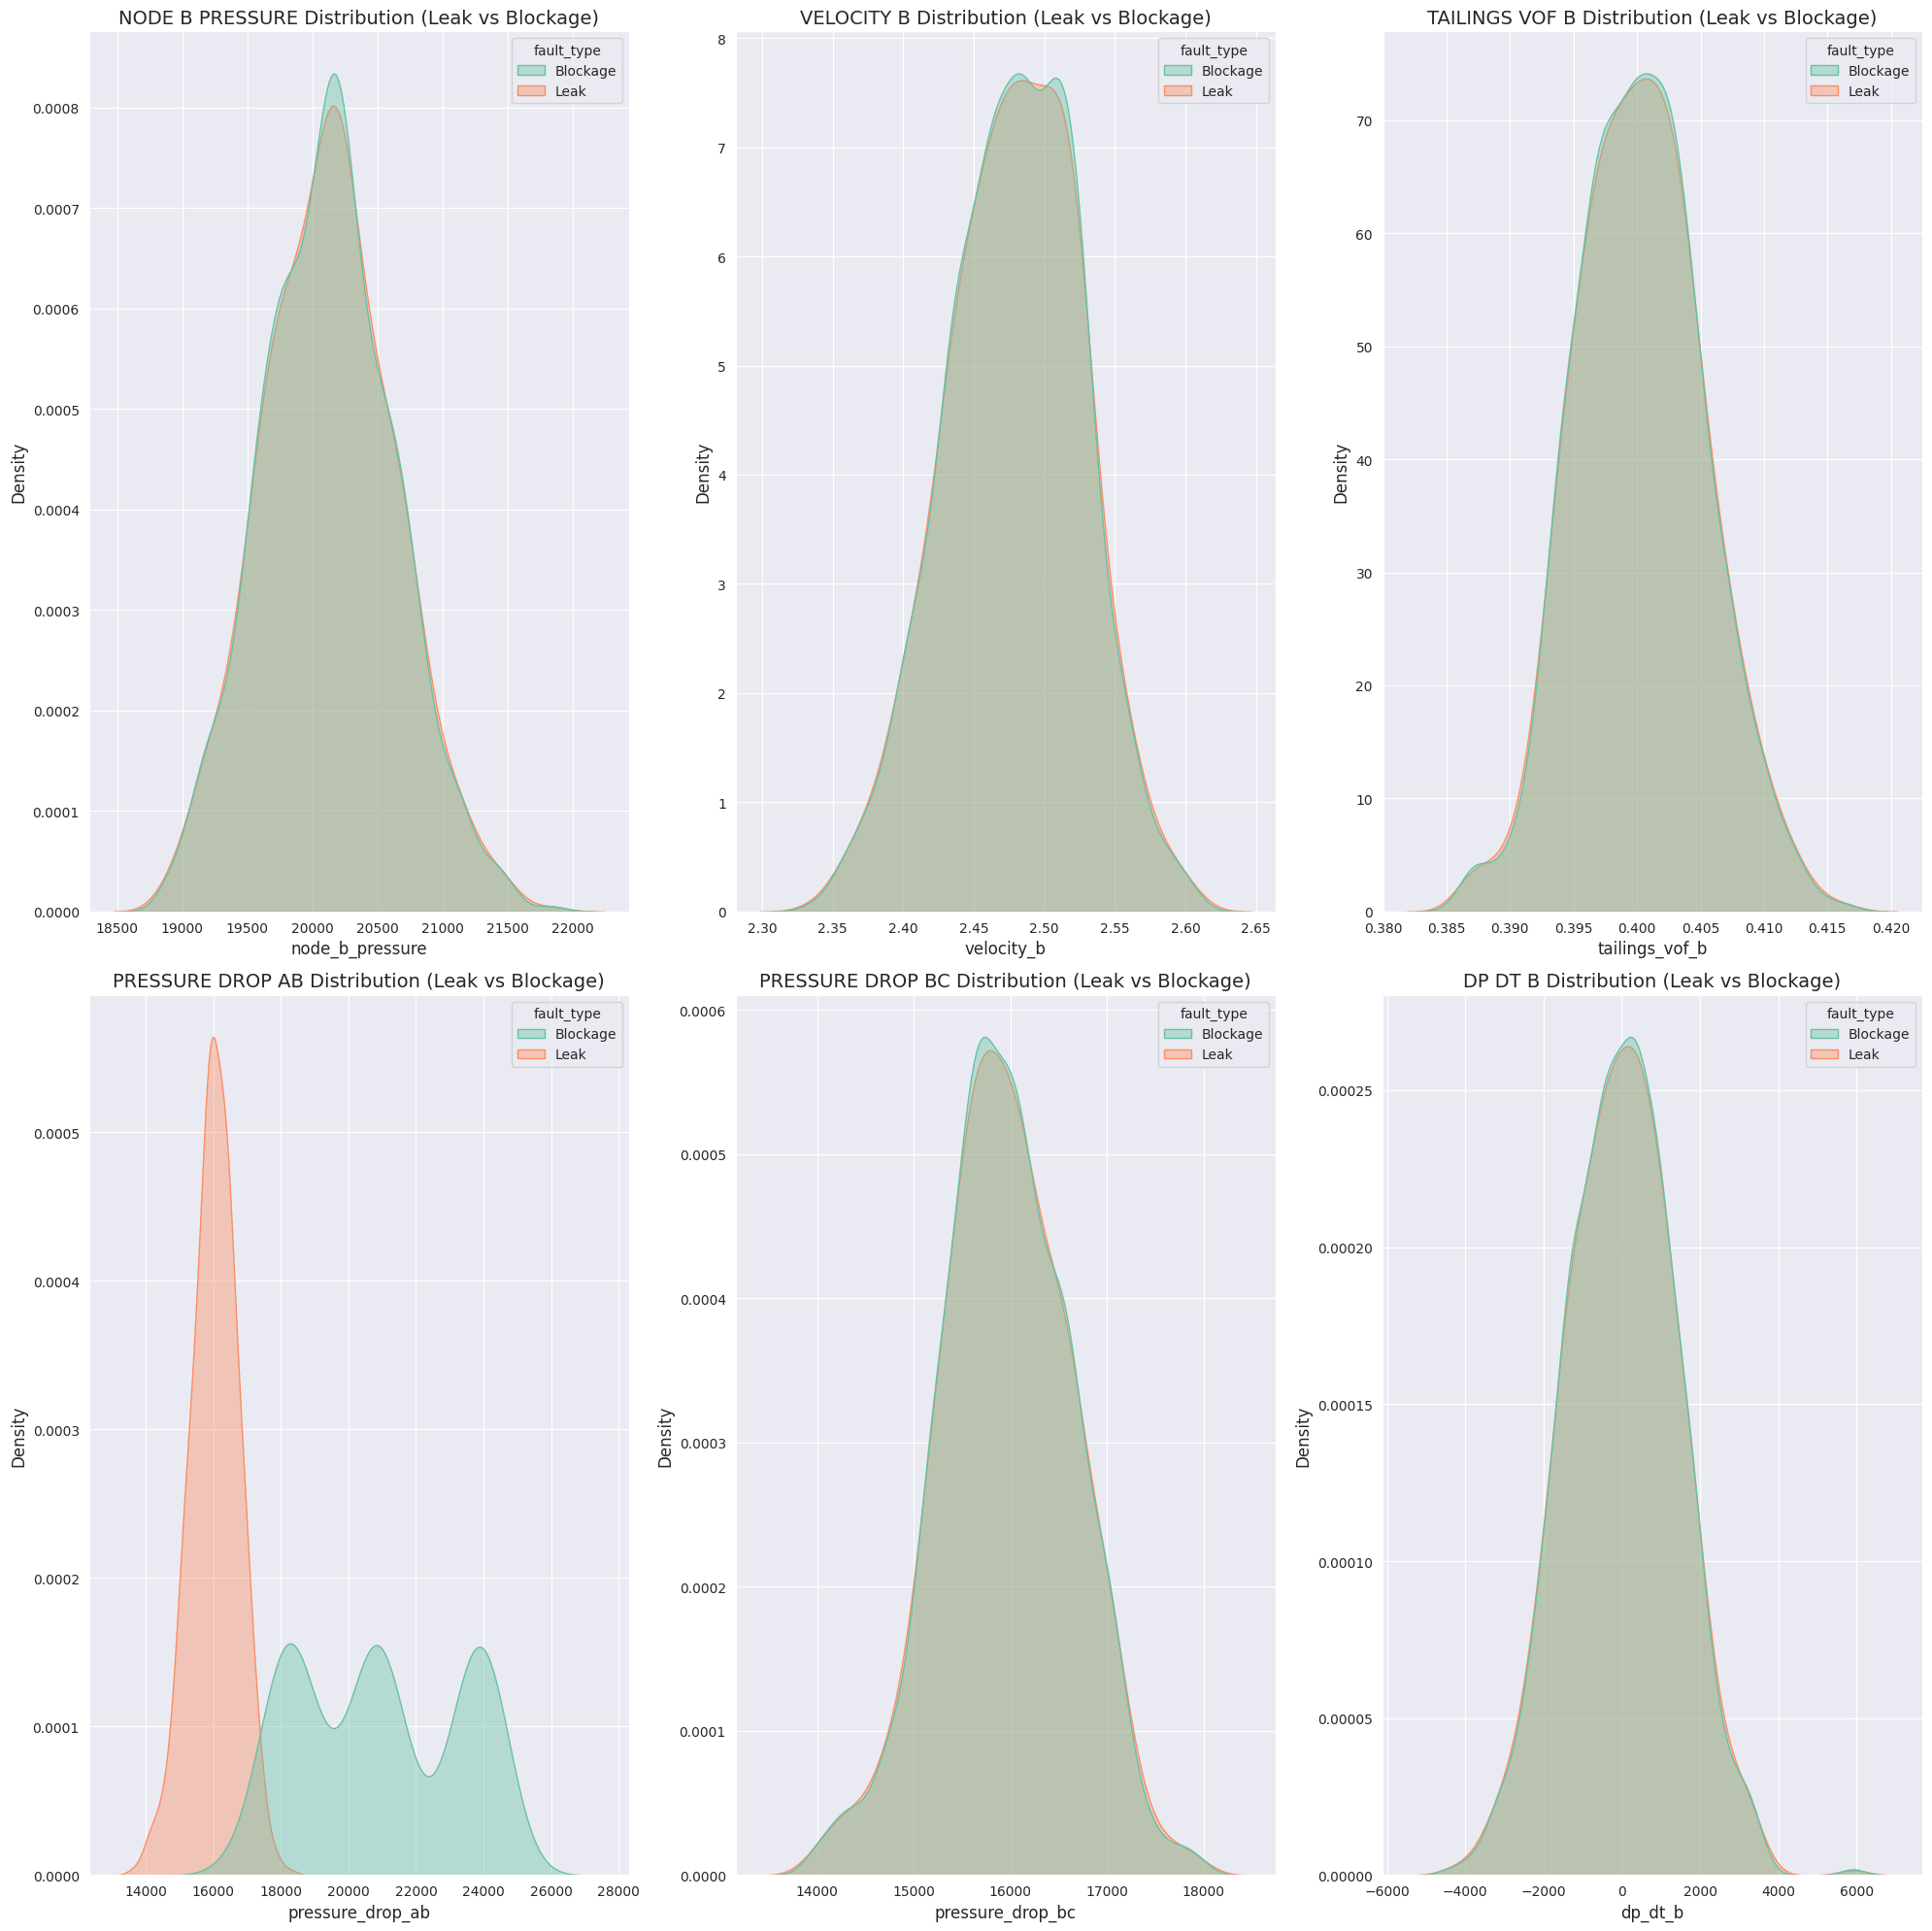

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(20, 20))

for i, node in enumerate(["node_b_pressure", "velocity_b", "tailings_vof_b", "pressure_drop_ab", "pressure_drop_bc", "dp_dt_b"]):
    sns.kdeplot(
        data=df[df["fault_type"].isin(["Leak", "Blockage"])],
        x=node,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i//3][i%3],
        palette="Set2"
    )

    axes[i//3][i%3].set_title(f"{node.replace('_', ' ').upper()} Distribution (Leak vs Blockage)", fontsize=14)
    axes[i//3][i%3].set_xlabel(node, fontsize=12)
    axes[i//3][i%3].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()

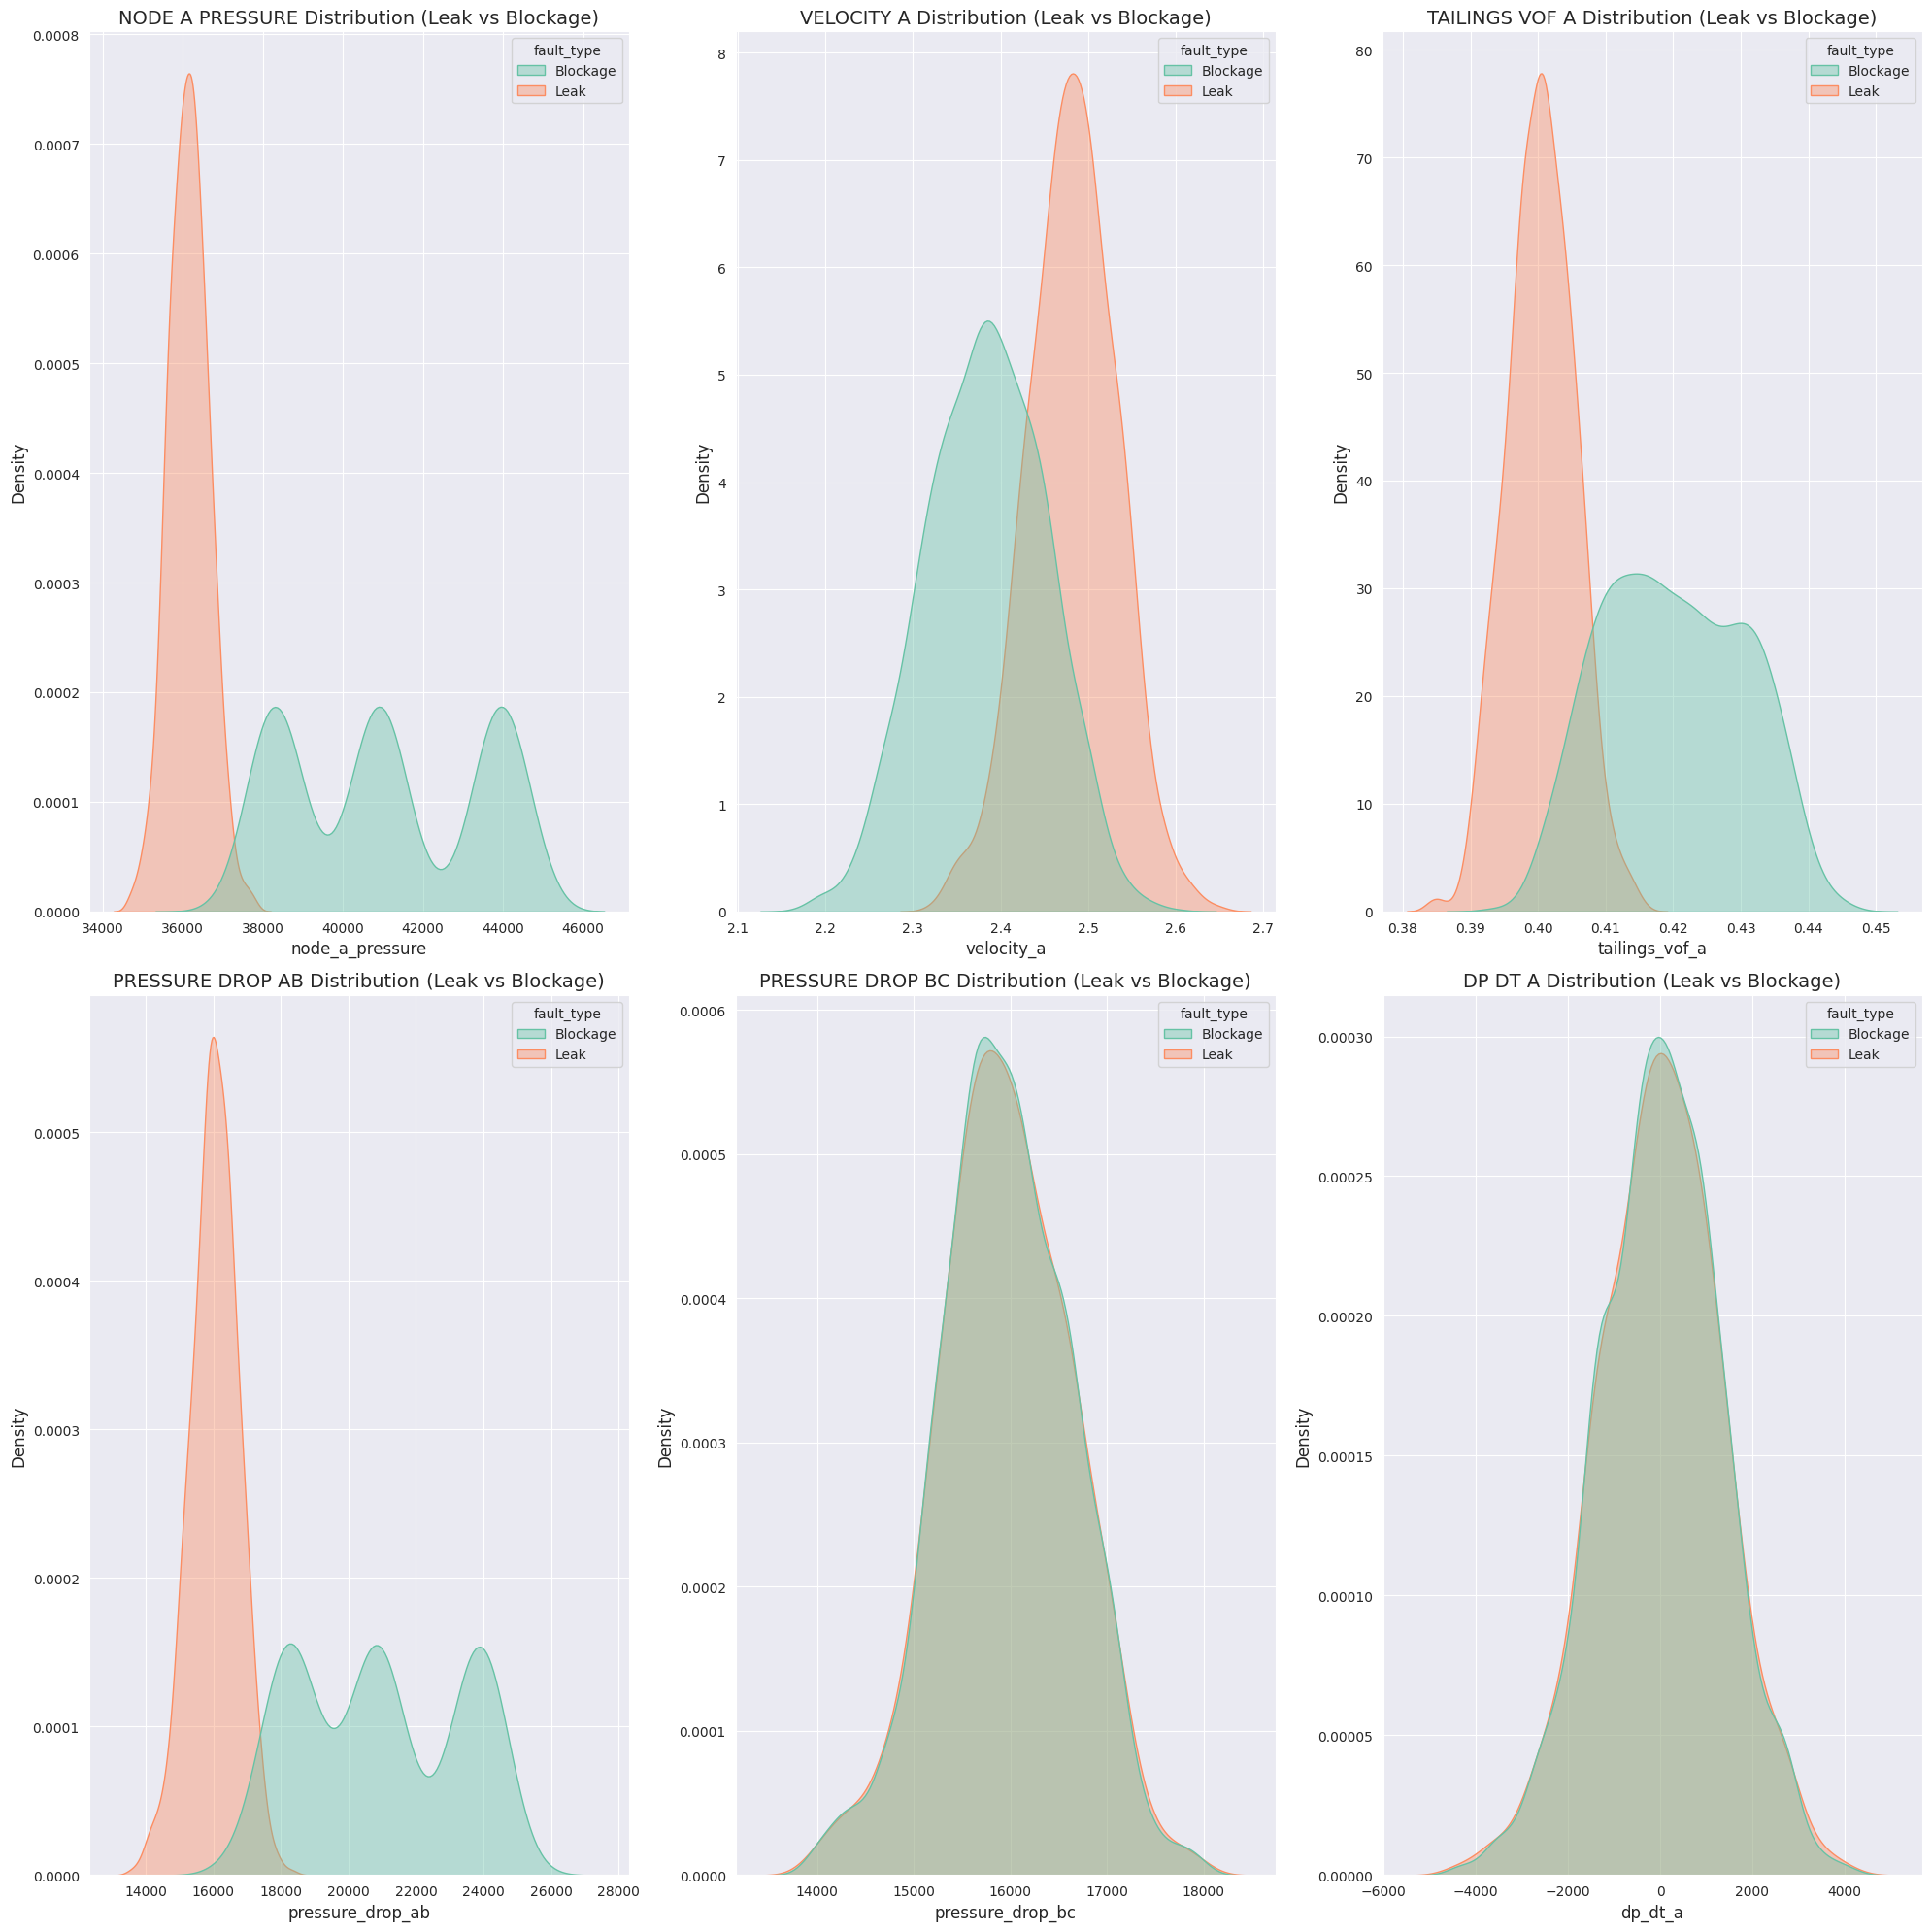

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(20, 20))

for i, node in enumerate(["node_a_pressure", "velocity_a", "tailings_vof_a", "pressure_drop_ab", "pressure_drop_bc", "dp_dt_a"]):
    sns.kdeplot(
        data=df[df["fault_type"].isin(["Leak", "Blockage"])],
        x=node,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i//3][i%3],
        palette="Set2"
    )

    axes[i//3][i%3].set_title(f"{node.replace('_', ' ').upper()} Distribution (Leak vs Blockage)", fontsize=14)
    axes[i//3][i%3].set_xlabel(node, fontsize=12)
    axes[i//3][i%3].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()

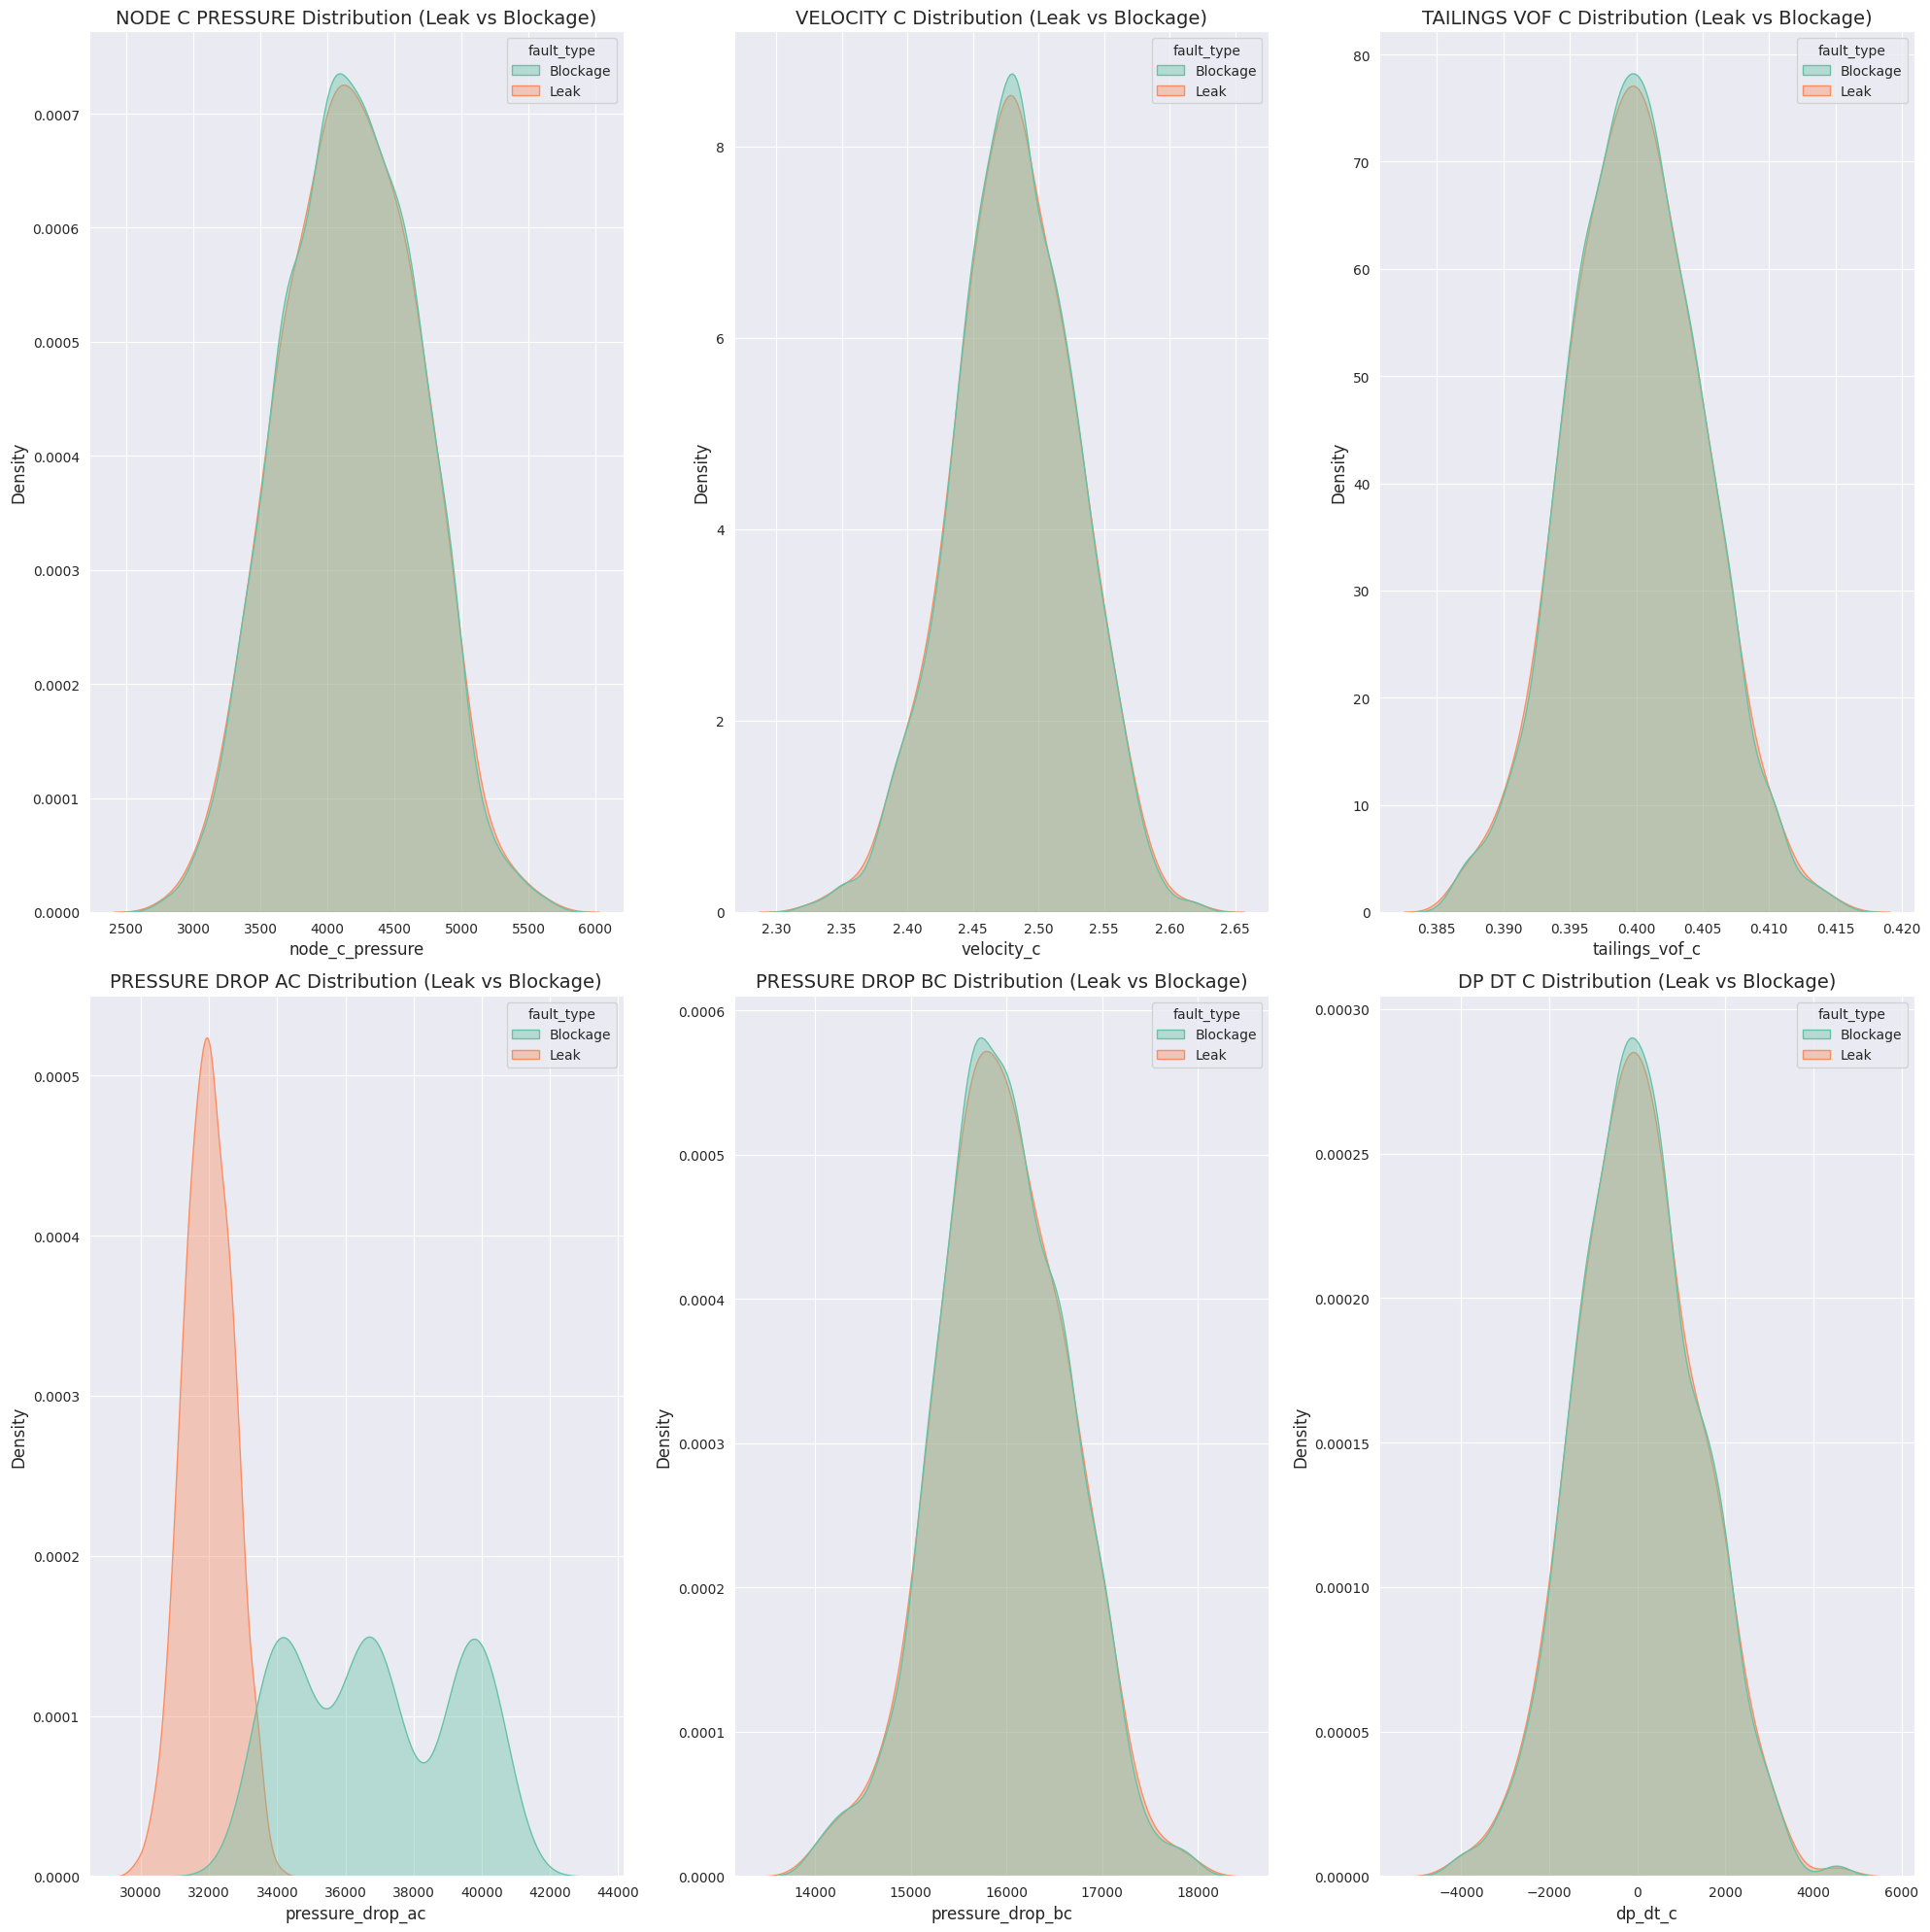

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(20, 20))

for i, node in enumerate(["node_c_pressure", "velocity_c", "tailings_vof_c", "pressure_drop_ac", "pressure_drop_bc", "dp_dt_c"]):
    sns.kdeplot(
        data=df[df["fault_type"].isin(["Leak", "Blockage"])],
        x=node,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i//3][i%3],
        palette="Set2"
    )

    axes[i//3][i%3].set_title(f"{node.replace('_', ' ').upper()} Distribution (Leak vs Blockage)", fontsize=14)
    axes[i//3][i%3].set_xlabel(node, fontsize=12)
    axes[i//3][i%3].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()

### Full Correlation Heatmap

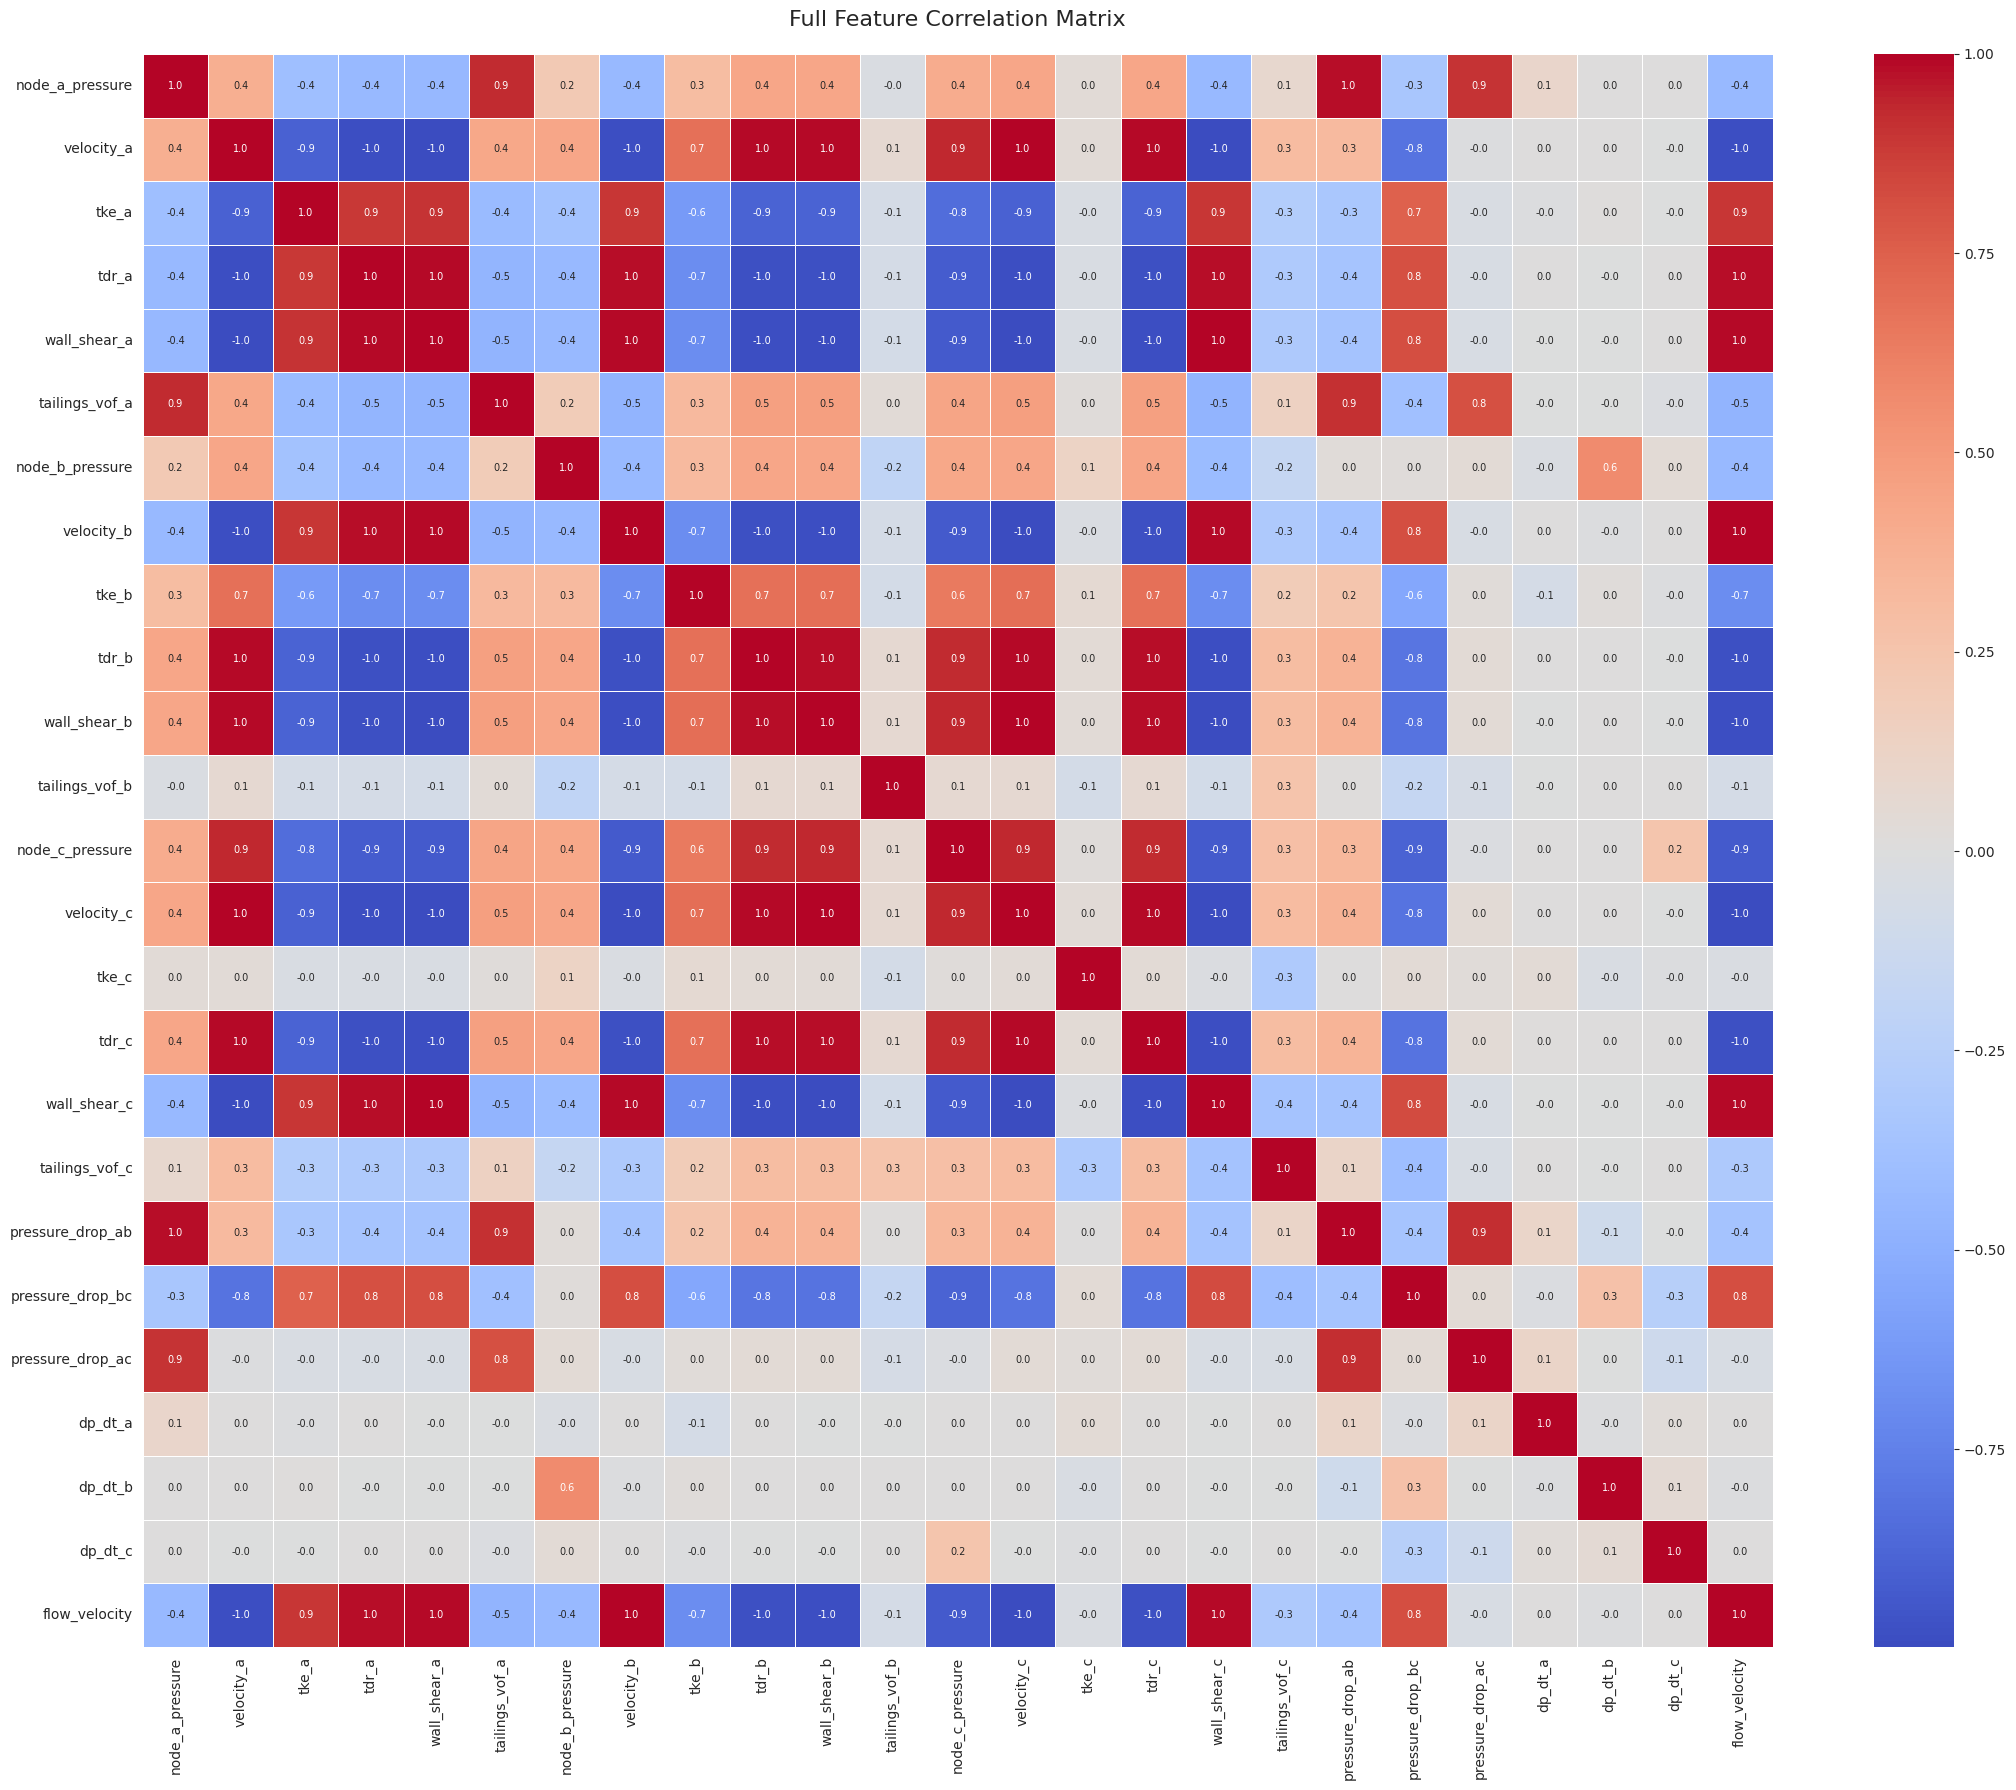


PAIRS WITH ABS(CORRELATION) > 0.95 — DROP CANDIDATES
Feature 1                 Feature 2                  Correlation
-----------------------------------------------------------------
node_a_pressure           pressure_drop_ab                0.9821
velocity_a                tdr_a                          -0.9836
velocity_a                wall_shear_a                   -0.9968
velocity_a                velocity_b                     -0.9894
velocity_a                tdr_b                           0.9874
velocity_a                wall_shear_b                    0.9915
velocity_a                velocity_c                      0.9966
velocity_a                tdr_c                           0.9877
velocity_a                wall_shear_c                   -0.9949
velocity_a                flow_velocity                  -0.9894
tdr_a                     wall_shear_a                    0.9852
tdr_a                     velocity_b                      0.9781
tdr_a                     tdr_b    

In [51]:
drop_cols = ['timestep', 'label', 'effect_factor', 'fault_type', 'scenario_id']
numeric_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Full Feature Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# High correlation pairs
print("\n" + "="*60)
print("PAIRS WITH ABS(CORRELATION) > 0.95 — DROP CANDIDATES")
print("="*60)
print(f"{'Feature 1':<25} {'Feature 2':<25} {'Correlation':>12}")
print("-"*65)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.95:
            f1 = corr_matrix.columns[i]
            f2 = corr_matrix.columns[j]
            high_corr_pairs.append((f1, f2, val))
            print(f"{f1:<25} {f2:<25} {val:>12.4f}")

print("\n" + "="*60)
print("PAIRS WITH ABS(CORRELATION) > 0.85 — WATCH LIST")
print("="*60)
print(f"{'Feature 1':<25} {'Feature 2':<25} {'Correlation':>12}")
print("-"*65)

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if 0.85 < abs(val) <= 0.95:
            f1 = corr_matrix.columns[i]
            f2 = corr_matrix.columns[j]
            print(f"{f1:<25} {f2:<25} {val:>12.4f}")

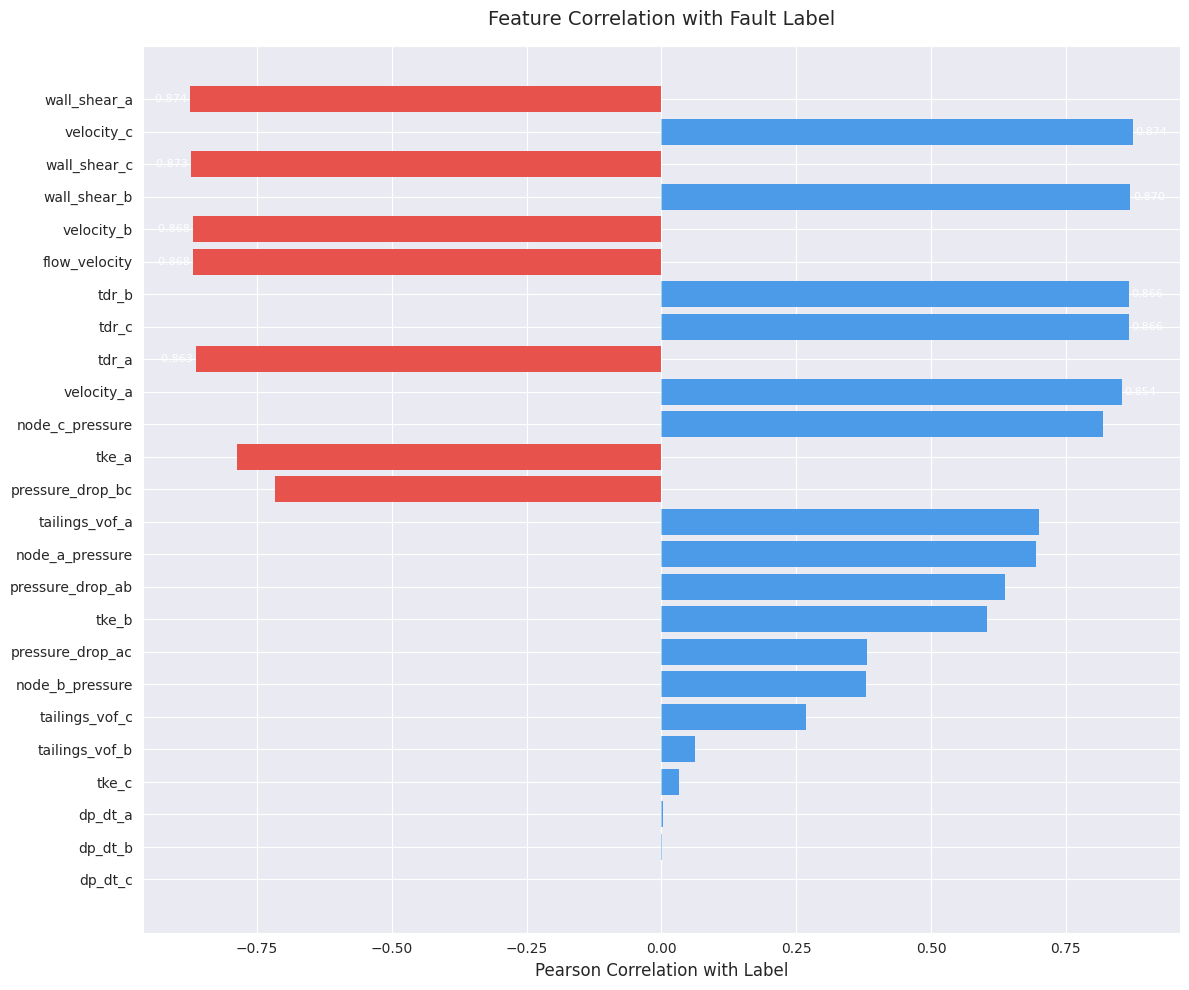


FEATURE CORRELATION WITH LABEL — RANKED
Rank   Feature                       Correlation      Abs
----------------------------------------------------------
1      wall_shear_a                      -0.8744   0.8744
2      velocity_c                         0.8742   0.8742
3      wall_shear_c                      -0.8728   0.8728
4      wall_shear_b                       0.8698   0.8698
5      velocity_b                        -0.8682   0.8682
6      flow_velocity                     -0.8682   0.8682
7      tdr_b                              0.8663   0.8663
8      tdr_c                              0.8662   0.8662
9      tdr_a                             -0.8627   0.8627
10     velocity_a                         0.8537   0.8537
11     node_c_pressure                    0.8182   0.8182
12     tke_a                             -0.7863   0.7863
13     pressure_drop_bc                  -0.7175   0.7175
14     tailings_vof_a                     0.7004   0.7004
15     node_a_pressure        

In [52]:
# Full correlation with labels
label_corr = numeric_df.copy()
label_corr['label'] = df['label']

corr_with_label = label_corr.corr()['label'].drop('label')
corr_with_label = corr_with_label.sort_values(key=abs, ascending=False)

colors = ['#4C9BE8' if v >= 0 else '#E8524C' for v in corr_with_label]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(corr_with_label.index, corr_with_label.values, color=colors, edgecolor='none')
ax.axvline(x=0, color='white', linewidth=0.8, alpha=0.5)

for i, (val, bar) in enumerate(zip(corr_with_label.values, bars)):
    if i < 10:
        ax.text(
            val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8,
            color='white'
        )

ax.set_xlabel("Pearson Correlation with Label", fontsize=12)
ax.set_title("Feature Correlation with Fault Label", fontsize=14, pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FEATURE CORRELATION WITH LABEL — RANKED")
print("="*60)
print(f"{'Rank':<6} {'Feature':<28} {'Correlation':>12} {'Abs':>8}")
print("-"*58)
for rank, (feat, val) in enumerate(corr_with_label.items(), 1):
    print(f"{rank:<6} {feat:<28} {val:>12.4f} {abs(val):>8.4f}")

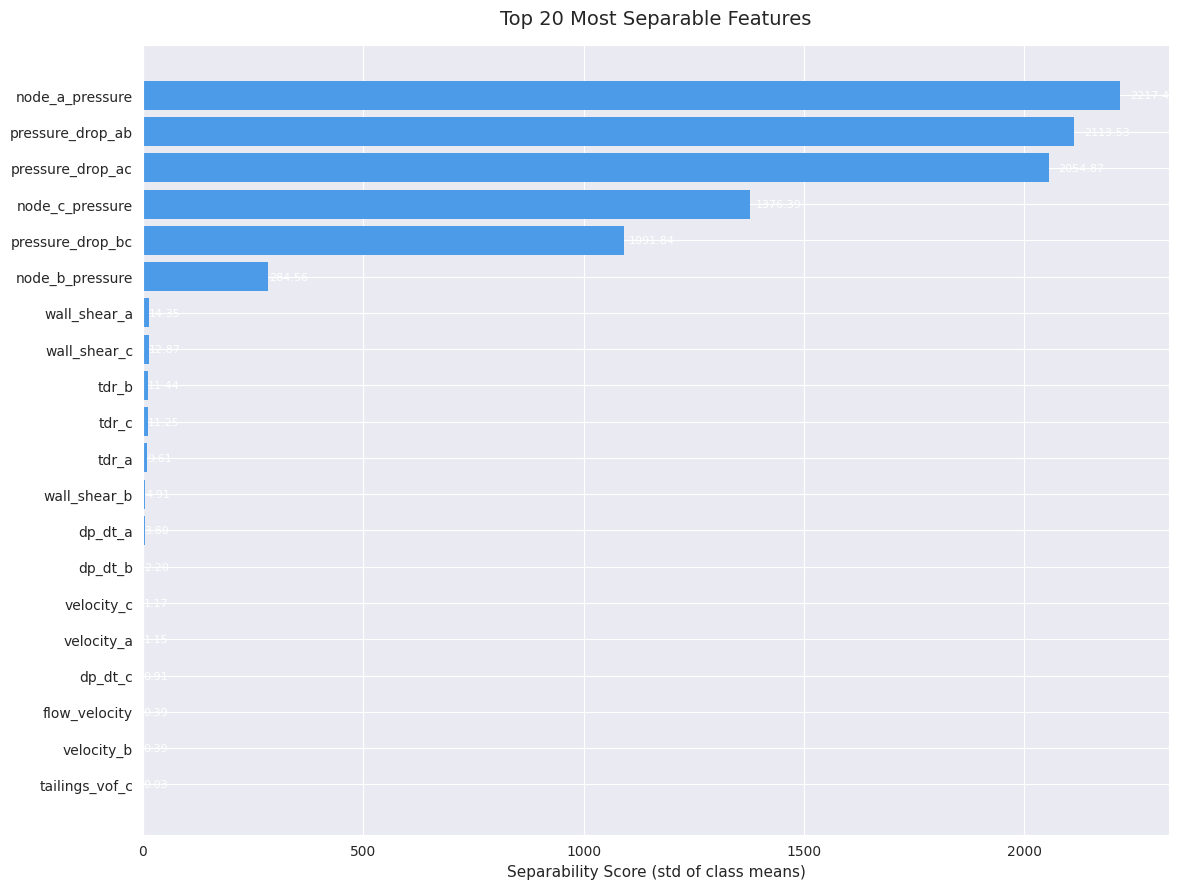


TOP 10 BEST FEATURES
         feature  separability
 node_a_pressure   2217.473773
pressure_drop_ab   2113.526699
pressure_drop_ac   2054.867107
 node_c_pressure   1376.393095
pressure_drop_bc   1091.835100
 node_b_pressure    284.560327
    wall_shear_a     14.348916
    wall_shear_c     12.872459
           tdr_b     11.438542
           tdr_c     11.254848

BOTTOM 5 WEAKEST FEATURES
       feature  separability
tailings_vof_a      0.009387
         tke_a      0.004371
tailings_vof_b      0.003155
         tke_b      0.002021
         tke_c      0.000080

Features with score < 0.01 (drop candidates): ['tailings_vof_a', 'tke_a', 'tailings_vof_b', 'tke_b', 'tke_c']


In [53]:
separability_scores = []

for col in numeric_df.columns:
    mean_normal   = df[df['label'] == 0][col].mean()
    mean_leak     = df[df['label'] == 1][col].mean()
    mean_blockage = df[df['label'] == 2][col].mean()
    score = np.std([mean_normal, mean_leak, mean_blockage])
    separability_scores.append({
        'feature':        col,
        'mean_normal':    mean_normal,
        'mean_leak':      mean_leak,
        'mean_blockage':  mean_blockage,
        'separability':   score
    })

sep_df = pd.DataFrame(separability_scores).sort_values('separability', ascending=False)

top20 = sep_df.head(20)
fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(top20['feature'], top20['separability'], color='#4C9BE8', edgecolor='none')
ax.invert_yaxis()

for bar, val in zip(bars, top20['separability']):
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va='center', fontsize=8, color='white'
    )

ax.set_xlabel("Separability Score (std of class means)", fontsize=11)
ax.set_title("Top 20 Most Separable Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TOP 10 BEST FEATURES")
print("="*60)
print(sep_df[['feature', 'separability']].head(10).to_string(index=False))

print("\n" + "="*60)
print("BOTTOM 5 WEAKEST FEATURES")
print("="*60)
print(sep_df[['feature', 'separability']].tail(5).to_string(index=False))

weak_features = sep_df[sep_df['separability'] < 0.01]['feature'].tolist()
print(f"\nFeatures with score < 0.01 (drop candidates): {weak_features}")

Top 6 features selected for pairplot:
['node_a_pressure', 'pressure_drop_ab', 'pressure_drop_ac', 'node_c_pressure', 'pressure_drop_bc', 'node_b_pressure']


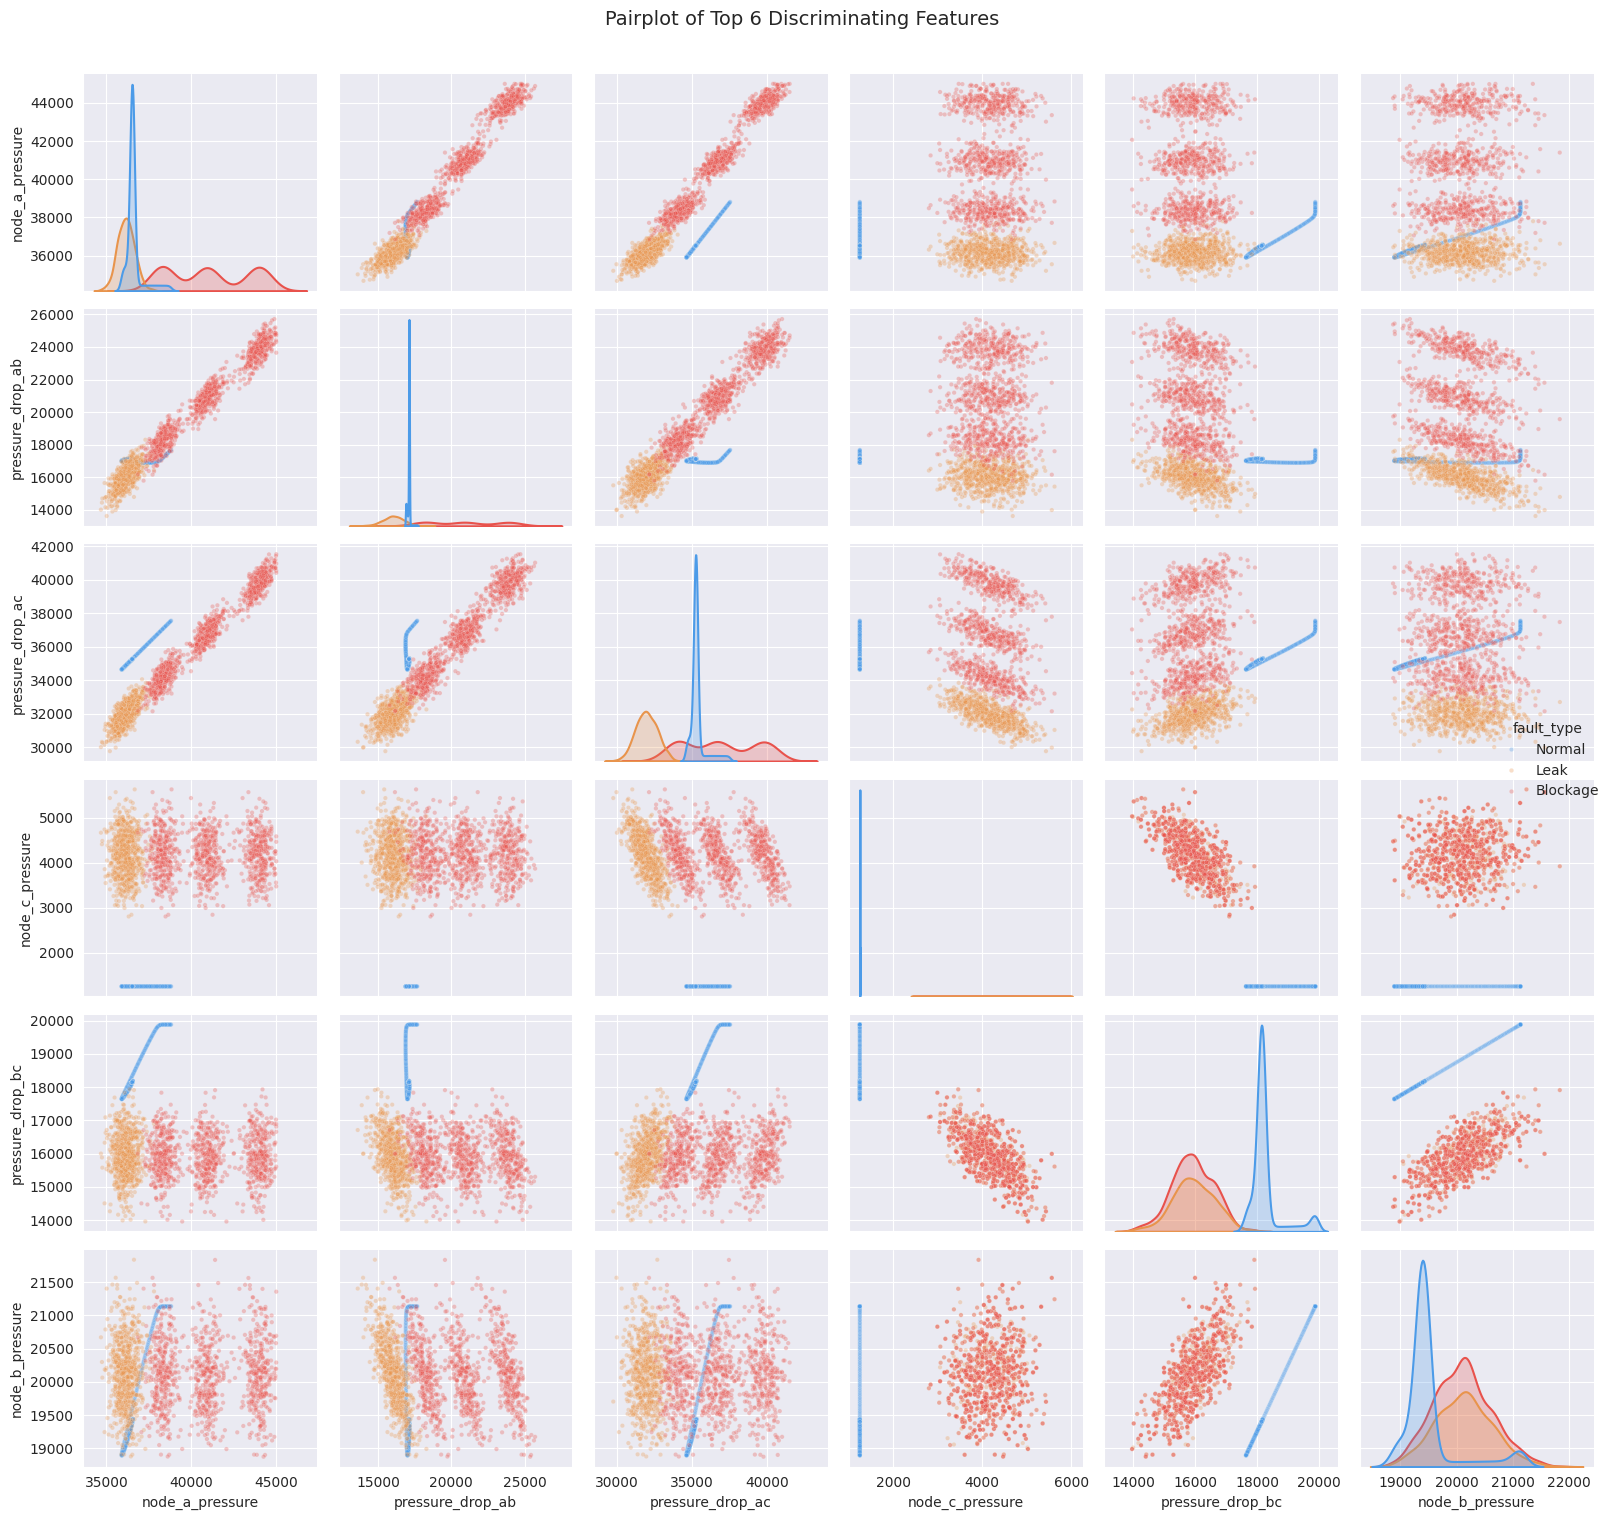

In [54]:
# Top 6 features
top6_features = sep_df['feature'].head(6).tolist()
print("Top 6 features selected for pairplot:")
print(top6_features)

# Safe sampling per class
sample_per_class = 1000

sampled = (
    df.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=42))
      .reset_index(drop=True)
)

# Build pairplot dataframe
pair_df = sampled[top6_features + ['fault_type']]

# Color palette
palette = {
    'Normal':   '#4C9BE8',
    'Leak':     '#E8944C',
    'Blockage': '#E8524C'
}

# Pairplot
g = sns.pairplot(
    pair_df,
    hue='fault_type',
    palette=palette,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kws={'linewidth': 1.5}
)

g.fig.suptitle("Pairplot of Top 6 Discriminating Features", y=1.01, fontsize=14)

plt.tight_layout()
plt.show()

In [55]:
print("=" * 60)
print("EDA KEY FINDINGS")
print("=" * 60)

print("\n── SECTION 1: DATA QUALITY ──────────────────────────────")
print(f"  Shape              : {df.shape}")
print(f"  Null values        : {df.isnull().sum().sum()}")
print(f"  Label distribution :")
print(df['label'].value_counts().to_string())
print(f"  Pressure range     : {df['node_a_pressure'].min():.1f} → {df['node_a_pressure'].max():.1f} Pa")
print(f"  Velocity range     : {df['velocity_a'].min():.3f} → {df['velocity_a'].max():.3f} m/s")
print(f"  VOF range          : {df['tailings_vof_a'].min():.4f} → {df['tailings_vof_a'].max():.4f}")

print("\n── SECTION 2: CLASS SEPARABILITY ────────────────────────")
print("  Top 10 features by separability score:")
for _, row in sep_df.head(10).iterrows():
    print(f"    {row['feature']:<28} score = {row['separability']:.4f}")
print("\n  Bottom 5 weakest features:")
for _, row in sep_df.tail(5).iterrows():
    print(f"    {row['feature']:<28} score = {row['separability']:.4f}")

print("\n── SECTION 3: PRESSURE SIGNATURE ───────────────────────")
b_a  = df[df['label']==2]['node_a_pressure'].mean()
n_a  = df[df['label']==0]['node_a_pressure'].mean()
b_b  = df[df['label']==2]['node_b_pressure'].mean()
b_c  = df[df['label']==2]['node_c_pressure'].mean()
n_c  = df[df['label']==0]['node_c_pressure'].mean()
l_c  = df[df['label']==1]['node_c_pressure'].mean()
print(f"  Node A elevated for Blockage : {'YES' if b_a > n_a else 'NO'} ({b_a:.0f} vs {n_a:.0f} Pa)")
print(f"  Node B elevated for Blockage : YES ({b_b:.0f} Pa vs Normal ~{df[df['label']==0]['node_b_pressure'].mean():.0f} Pa)")
print(f"  Node C reduced for Blockage  : {'YES' if b_c < n_c else 'NO'} ({b_c:.0f} vs {n_c:.0f} Pa)")
print(f"  Node C reduced for Leak      : {'YES' if l_c < n_c else 'NO'} ({l_c:.0f} vs {n_c:.0f} Pa)")

print("\n── SECTION 4: VELOCITY SIGNATURE ───────────────────────")
b_vb = df[df['label']==2]['velocity_b'].mean()
n_vb = df[df['label']==0]['velocity_b'].mean()
l_vc = df[df['label']==1]['velocity_c'].mean()
n_vc = df[df['label']==0]['velocity_c'].mean()
print(f"  Node B velocity lowest for Blockage  : {'YES' if b_vb < n_vb else 'NO'} ({b_vb:.4f} vs {n_vb:.4f} m/s)")
print(f"  Node C velocity reduced for Leak     : {'YES' if l_vc < n_vc else 'NO'} ({l_vc:.4f} vs {n_vc:.4f} m/s)")

print("\n── SECTION 5: VOF SIGNATURE ─────────────────────────────")
l_vof_b  = df[df['label']==1]['tailings_vof_b'].mean()
n_vof_b  = df[df['label']==0]['tailings_vof_b'].mean()
b_vof_a  = df[df['label']==2]['tailings_vof_a'].mean()
n_vof_a  = df[df['label']==0]['tailings_vof_a'].mean()
print(f"  VOF drops at leak node B     : {'YES' if l_vof_b < n_vof_b else 'NO'} ({l_vof_b:.4f} vs {n_vof_b:.4f})")
print(f"  VOF rises upstream blockage A: {'YES' if b_vof_a > n_vof_a else 'NO'} ({b_vof_a:.4f} vs {n_vof_a:.4f})")

print("\n── SECTION 6: LEAK VS BLOCKAGE SEPARABILITY ─────────────")
print("  Best separating features (Leak vs Blockage):")
for _, row in sep_df.head(5).iterrows():
    lm = df[df['label']==1][row['feature']].mean()
    bm = df[df['label']==2][row['feature']].mean()
    print(f"    {row['feature']:<28} Leak={lm:.2f}  Blockage={bm:.2f}")
print("  Leak vs Normal difficulty: HIGH — raw features show <1% mean difference")

print("\n── SECTION 7: REDUNDANT FEATURES TO DROP ────────────────")
if high_corr_pairs:
    for f1, f2, val in high_corr_pairs:
        print(f"  DROP one of: {f1} / {f2}  (corr={val:.3f})")
else:
    print("  No pairs above 0.95 threshold found")
print("  ALWAYS DROP: dp_dt_a, dp_dt_b, dp_dt_c (zero class separation)")
print("  ALWAYS DROP: effect_factor (generation parameter)")
print("  ALWAYS DROP: flow_velocity (duplicate of velocity_b)")
print("  ALWAYS DROP: timestep, fault_type, scenario_id")

EDA KEY FINDINGS

── SECTION 1: DATA QUALITY ──────────────────────────────
  Shape              : (3500, 29)
  Null values        : 0
  Label distribution :
label
2    2100
1     700
0     700
  Pressure range     : 34676.2 → 45000.0 Pa
  Velocity range     : 0.000 → 2.646 m/s
  VOF range          : 0.3846 → 0.4464

── SECTION 2: CLASS SEPARABILITY ────────────────────────
  Top 10 features by separability score:
    node_a_pressure              score = 2217.4738
    pressure_drop_ab             score = 2113.5267
    pressure_drop_ac             score = 2054.8671
    node_c_pressure              score = 1376.3931
    pressure_drop_bc             score = 1091.8351
    node_b_pressure              score = 284.5603
    wall_shear_a                 score = 14.3489
    wall_shear_c                 score = 12.8725
    tdr_b                        score = 11.4385
    tdr_c                        score = 11.2548

  Bottom 5 weakest features:
    tailings_vof_a               score = 0.0094
   

In [56]:
processed_path = Path.cwd().parent / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)

# Class statistics
class_stats = df.groupby('fault_type')[numeric_df.columns].agg(['mean', 'std'])
class_stats.to_csv(processed_path / "eda_class_statistics.csv")
print(f"Saved: eda_class_statistics.csv")

# Separability scores
sep_df.to_csv(processed_path / "eda_separability_scores.csv", index=False)
print(f"Saved: eda_separability_scores.csv")

# Top features list
top_features = sep_df[sep_df['separability'] >= 0.01]['feature'].tolist()
with open(processed_path / "top_features.txt", "w") as f:
    for feat in top_features:
        f.write(feat + "\n")
print(f"Saved: top_features.txt  ({len(top_features)} features)")

# Redundant feature pairs
with open(processed_path / "redundant_features.txt", "w") as f:
    f.write("PAIRS WITH CORRELATION > 0.95 — DROP ONE FROM EACH PAIR\n")
    f.write("="*60 + "\n")
    for f1, f2, val in high_corr_pairs:
        f.write(f"{f1} / {f2}  (corr={val:.4f})\n")
    f.write("\nALWAYS DROP\n")
    f.write("="*60 + "\n")
    always_drop = ['dp_dt_a', 'dp_dt_b', 'dp_dt_c',
                   'effect_factor', 'flow_velocity',
                   'timestep', 'fault_type', 'scenario_id']
    for col in always_drop:
        f.write(col + "\n")
print(f"Saved: redundant_features.txt")

print("\n" + "="*60)
print("EDA COMPLETE")
print("Ready for → 02_feature_engineering.ipynb")
print("="*60)

Saved: eda_class_statistics.csv
Saved: eda_separability_scores.csv
Saved: top_features.txt  (20 features)
Saved: redundant_features.txt

EDA COMPLETE
Ready for → 02_feature_engineering.ipynb
